# Phase Analyzer

Analyzes the phase patterns, modelled as genetic instances, after optimization 

In [2]:
# Functions to import

import numpy as np 
import scipy as sp
import pygad
import yaml 
from yaml import Loader 

from scipy.fft import fft2, fftfreq, ifft2, fftshift, ifftshift
from scipy import ndimage
from optical_functions import TotInt, LG, propFF, cart2pol, oamModes, output_chan, setKnotType, output_chan_symmetric, output_chan_triangle, output_chan_circle, norm_field
from knot_funcs import propTF
#from run_ga import compute_sorting_performance

import matplotlib.pyplot as plt 

import os

# Physical Constants

nm = 1e-9
um = 1e-6
mm = 1e-3
cm = 1e-2

# Create field & modes of interest following yaml configuration

Initialize coordinate space and system parameters that we will use to define our field.

In [3]:
import pickle

index = 7
#experiment_name = "Knot Sorting Bread"
#experiment_name = "Knot Sorting New FF"
#experiment_name = "Knot Sorting Three Knot Fun"
experiment_name = "Knot Sorting New FF Smaller Alpha"
#experiment_name = "Knot Sorting New FF Large Alpha"

stream = open(f"configs/{experiment_name}/ga{index}.yaml", 'r')
cnfg = yaml.load(stream, Loader=Loader)

cnfg.setdefault('circle_radius', 1.5)
cnfg.setdefault('alpha', 0.0)

N = cnfg['dim']
num_of_output_chans = cnfg['num_output_chans']
output_chan_width = cnfg['output_chan_width'] * mm # in mm 
output_chan_width = 0.25 * mm # in mm 

num_phase_maps_near = cnfg['num_phase_maps_near']
num_phase_maps_far = cnfg['num_phase_maps_far']

num_of_phase_maps = num_phase_maps_near + num_phase_maps_far # Total number of phase maps
instance_name = cnfg['ga_instance'] # directory name of best phases

# Print the instance name (for reference)

print(instance_name)

# Some parameters specifying the LG modes

LG_modes = cnfg['LG_modes']
w0 = cnfg['w0'] * mm # in mm!!

isKnot = cnfg['isKnot']
knotType = cnfg['knotType']
shapeParams = cnfg['shapeParams']
fourier_lens = cnfg['fourier_length']*cm # fourier length of both lens in cm
GFilterStrength=cnfg['gauss_filter_sigma']
channel_seperation = cnfg['channel_sep']
circle_radius = cnfg['circle_radius'] # circle radius is in mm
alpha = cnfg['alpha']

# Define the coordinate space 

la = 0.78*um
k=(2*np.pi)/la  # [m^-1] wavenumber    
N=128 # [Number of points per dimension]
maxx = 20*um*N  # Full length of the numerical window (m)

# Propagation Distance 
prop_dist = 0

# Let's apply a rotation
rot_phi = eval(cnfg['rot_angle'])

# Space definition 
dx = maxx/N
dy = maxx/N 

#okay let's just say h here is dx or dy for now WLOG (WITH ... loss of generality)

h = dx
X = dx*(np.arange(N) - N //2)
Y = dy*(np.arange(N) - N //2)

# Apply rotation operator on coords 

xx,yy=np.meshgrid(X ,Y)

r, phi= cart2pol(xx, yy)

# What experiment are we going to design

simulateLens = cnfg['simulateLens']
multiPhase = cnfg['multiPhase']
multiPhaseLens = cnfg['multiPhaseLens']

z_o = cnfg['z_o']*cm
fourier_lens = cnfg['fourier_length']

''' 
Create the OAM beams that we need to sort 
'''
# Now create a list containing 'oamMode' objects 

list_of_OAMs = []

output_chans = output_chan_circle(X, Y, output_chan_width, maxx, num_of_output_chans, circle_radius=circle_radius)

if(isKnot):
    for ii in range(len(knotType)):
        field = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
        prop_field = field
        list_of_OAMs.append(oamModes(prop_field, output_chans[ii]))
else:
    for ii in range(len(LG_modes)):
        ell, p = LG_modes[ii][0], LG_modes[ii][1]
        field = LG(r, phi, ell, p, w0, h, 0, k)
        prop_field = propTF(field, maxx, la, prop_dist)
        list_of_OAMs.append(oamModes(prop_field, output_chans[ii]))


# Load up phase screens

with open(f"best_phases/{instance_name}.pkl", 'rb') as file:
     phase_out = pickle.load(file)


cinque_hopf_tref_two_sc_new_ff_small_alpha


Compute phase screens

In [4]:
phase_maps = np.empty((num_of_phase_maps, N, N), dtype=np.complex128)

# Compute phase screens
for ii in range(num_of_phase_maps):
    phase_maps[ii] = np.exp(1j * phase_out[ii])

Plot phase screens

Phase screens saved to: phase_screens.pdf


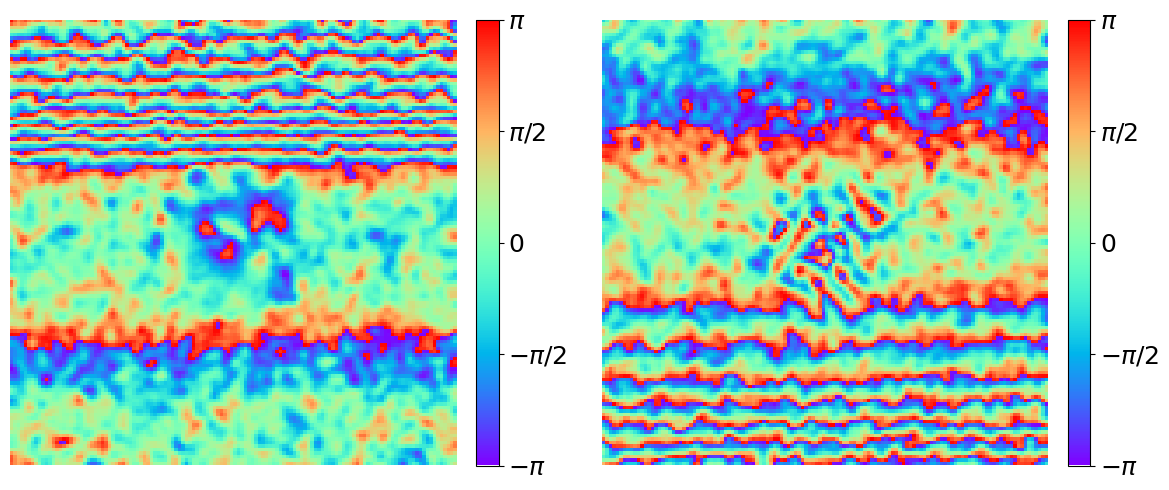

In [5]:
phase_maps = np.empty((num_of_phase_maps, N, N), dtype=np.complex128)

# Compute phase screens
for ii in range(num_of_phase_maps):
    phase_maps[ii] = np.exp(1j * phase_out[ii])

# Plot all phase screens in a subplot grid with colorbars
n_cols = int(np.ceil(np.sqrt(num_of_phase_maps)))
n_rows = int(np.ceil(num_of_phase_maps / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = np.array(axes).flatten() if num_of_phase_maps > 1 else np.array([axes])

for ps_index in range(num_of_phase_maps):
    im = axes[ps_index].imshow(np.angle(phase_maps[ps_index]), cmap='rainbow')
    axes[ps_index].axis('off')
    # Add colorbar to each phase screen with larger font and pi labels
    cbar = plt.colorbar(im, ax=axes[ps_index], fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=18)
    # Set custom ticks and labels in terms of pi
    cbar.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    cbar.set_ticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])

# Hide any unused subplots
for ps_index in range(num_of_phase_maps, len(axes)):
    axes[ps_index].axis('off')

plt.tight_layout()

# Save phase screens grid as PDF

phase_screens_pdf = "phase_screens.pdf"
fig.savefig(phase_screens_pdf, dpi=300, bbox_inches='tight')
print(f"Phase screens saved to: {phase_screens_pdf}")

plt.show()

# Crosstalk Matrix

We compute performance metrics of our experiment. We redefine the function that we use to do this here. 

In [6]:
from optical_functions import shannon_entropy
import time

def compute_sorting_performance(phase_maps, list_of_OAMs, alpha=1.0):

    # Make the dimensionality of our sorting in terms of # of modes
    d = len(list_of_OAMs)
    
    # Now, this is the fitness parameter 

    sorting_performance = np.zeros(d)

    # Also, compute the sorting probability
    sorting_probability = 0

    # Actually, let's introduce the crosstalk matrix 
    crosstalk_matrix = np.zeros((num_of_output_chans, num_of_output_chans))

    # Let's also introduce a new crosstalk matrix to compute the sorting probability
    crosstalk_prob = np.zeros((num_of_output_chans, num_of_output_chans))

    
    # Let's introduce the secret key rate here, actually. 
    secret_key = 0

    for ii in range(d):

        # Define initial OAM field and correct output channel 

        field = list_of_OAMs[ii].oamBeam 
        
        # Do a proper normalization on the incident field 
        
        field = norm_field(field,h)
        
        # Compute the initial field intensity. This will be important for later
        
        int_knot = np.sum(np.abs(field)**2)
    
        # modulate the field by the first phase map 

        field_mod_1 = field*phase_maps[0]

        # Proceed with our chosen experiment

        # Case 1: We are doing the experiment without any lenses

        if (multiPhase): # Propagate the field by a distance z_o and apply the second phase screen
            field_after = field_mod_1

            for jj in range(1, len(phase_maps)):
                # Propagate the beam by a distance z_o
                field_after = propTF(field_after, maxx, la, z_o)

                # Apply the next phase map (if applicable)
                field_after = field_after*phase_maps[jj]

            # Propagate the beam one final time and observe the final field

            final_field = propTF(field_after, maxx, la, z_o)

        else: # Case 2: We are computing the experiment with the lens 

            if (multiPhaseLens): # Multi-phase experiment with the lens
                field_after = field_mod_1

                for kk in range(1, num_phase_maps_near):
                    # Propagate the beam by a distance z_o 
                    field_after = propTF(field_after, maxx, la, z_o)
                    # Apply the next phase map in the near field (if applicable)
                    field_after = field_after*phase_maps[kk]
                
                # Fourier transform the beam into the far field
                field_lens = fftshift(fft2(field_after))

            elif (simulateLens): # We simulate Faunhofer Diffraction for a more accurate representation of lens propagation
                field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)
        
            
            else: # Compute the field at the front focal plane of the lens
                 field_lens = fftshift(fft2(field_mod_1))
        
            # What happens next depends on whether we have one or two phase maps
        
            if (num_phase_maps_far==0):
                # Compute the field intensity 
                final_field = field_lens
        
            else:
                # Modulate the field by the first far field map
                field_mod_2 = field_lens*phase_maps[num_phase_maps_near]
                if (multiPhaseLens):
                    field_after_2 = field_mod_2
                    
                    for ll in range(1+num_phase_maps_near, num_of_phase_maps):
                        # Propagate the beam 
                        field_after_2 = propTF(field_after_2, maxx, la, z_o)
                        # Apply phase to beam 
                        field_after_2 = field_after_2*phase_maps[ll]
            
                 # Apply inverse fourier transform onto beam
                    field_lens_2 = ifft2(ifftshift(field_after_2))

                 # simulate the lens field again. This is the final field. 
                elif (simulateLens):
                    field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
                else: 
                    field_lens_2 = ifft2(ifftshift(field_mod_2))

                final_field = field_lens_2
        
        # We normalize the final field and compute the intensity 
        
        final_field = norm_field(final_field,h)
        final_field_int = np.abs(final_field)**2
        
        # Define full set of indices, as you would summing through a for loop
        full_index = np.arange(len(output_chans))   
        # Delete ii from the list of full_index, creating a new temporary array
        temp_index = np.delete(full_index, ii)
        # Sum up the "incorrect" channels 
        incorrect_chans = 0
        # New: to construct our crosstalk matrix, let's store the individual intensities
        incorrect_chan_ints = []
        
        for ind in temp_index:
            field_in_pupil = final_field_int*output_chans[ind]
            incorrect_chan_ints.append(np.sum(field_in_pupil)/int_knot)
            incorrect_chans += np.sum(field_in_pupil)/int_knot
            
        # Now, evaluate the sorting performance 
        correct_chans = np.sum(final_field_int*output_chans[ii])/int_knot # normalization is mode-specific
        sorting_performance[ii] = correct_chans - incorrect_chans
        
        # Compute the detector effeciency 
        detect_eff = correct_chans 
        crosstalk_matrix[ii,ii] = detect_eff 

        # Update the sorting probability
        sorting_probability = correct_chans / (correct_chans + incorrect_chans)
        crosstalk_prob[ii, ii] = sorting_probability
        
        # Compute the crosstalk matrix. For more than two modes, we have to be a bit more meticulous with our approach. 
        
        for jj, ind in enumerate(temp_index):
            crosstalk_eff = incorrect_chan_ints[jj]
            crosstalk_matrix[ii, ind] = crosstalk_eff
            crosstalk_prob[ii, ind] = crosstalk_eff
        

    # Compute the "QBER" using the off-diagonals of the crosstalk matrix 
    qber = ((d-1)/d**2)*(crosstalk_matrix.sum() - np.trace(crosstalk_matrix)) # This bounds the qber to 1, in principle

    # Compute the secret key rate
    secret_key = np.log2(d) - 2*shannon_entropy(qber,d)

    # NEW: We keep track of the per-channel sorting performance
    # alpha is a hyperparameter which adjusts the weight between the minimum and the sum of sorting performances across each channel. 
    # At alpha=0.0, we recover the old behavior, while at alpha=1.0, we consider the minimum
    
    print(sorting_performance)

    overall_sort_perf = alpha*np.min(sorting_performance) - ((1-alpha)/d)*np.sum(sorting_performance)

    return overall_sort_perf, crosstalk_matrix, secret_key, crosstalk_prob

In [7]:
def visualize_input_output_fields(phase_maps, list_of_OAMs, figsize_per_mode=(6, 5), save_path=None, dpi=300, colorbar_fontsize=10):
   
    """
    Visualize all input fields and output fields in separate subplots.
    Creates two separate figures: one for inputs, one for outputs.

    Parameters:
    -----------
    phase_maps : array
        The phase maps used for beam modulation
    list_of_OAMs : list
        List of oamModes objects containing the input beams
    figsize_per_mode : tuple
        Figure size per mode (width, height). Total figure width = width * num_modes
    save_path : str, optional
        Base path to save figures. '_inputs' and '_outputs' with .png and .pdf extensions will be appended.
        If None, figures are not saved.
    dpi : int
        Resolution for saved figure (default: 300)
    colorbar_fontsize : int
        Font size for colorbar tick labels (default: 10)

    Returns:
    --------
    fig_input, axes_input : Input figure and axes
    fig_output, axes_output : Output figure and axes
    """
    d = len(list_of_OAMs)

    # Calculate figure sizes
    fig_width = figsize_per_mode[0] * d
    fig_height = figsize_per_mode[1]

    # Create separate figures for input and output
    fig_input, axes_input = plt.subplots(1, d, figsize=(fig_width, fig_height))
    fig_output, axes_output = plt.subplots(1, d, figsize=(fig_width, fig_height))

    # Handle case where d=1 (axes won't be an array)
    if d == 1:
        axes_input = [axes_input]
        axes_output = [axes_output]

    # First pass: compute all input and output intensities to determine global scales
    input_intensities = []
    output_intensities = []
    
    for ii in range(d):
        # Get initial field
        field = list_of_OAMs[ii].oamBeam
        field = norm_field(field, h)
        input_intensity = np.abs(field)**2
        input_intensities.append(input_intensity)
        
        # Compute output field (same logic as compute_sorting_performance)
        int_knot = np.sum(np.abs(field)**2)
        field_mod_1 = field * phase_maps[0]

        # Determine experiment type and compute final field
        if multiPhase:
            field_after = field_mod_1
            for jj in range(1, len(phase_maps)):
                field_after = propTF(field_after, maxx, la, z_o)
                field_after = field_after * phase_maps[jj]
            final_field = propTF(field_after, maxx, la, z_o)

        else:  # Experiment with lens
            if multiPhaseLens:
                field_after = field_mod_1
                for kk in range(1, num_phase_maps_near):
                    field_after = propTF(field_after, maxx, la, z_o)
                    field_after = field_after * phase_maps[kk]
                field_lens = fftshift(fft2(field_after))
            elif simulateLens:
                field_lens, _ = propFF(field_mod_1, maxx, la, fourier_lens)
            else:
                field_lens = fftshift(fft2(field_mod_1))

            if num_phase_maps_far == 0:
                final_field = field_lens
            else:
                field_mod_2 = field_lens * phase_maps[num_phase_maps_near]
                if multiPhaseLens:
                    field_after_2 = field_mod_2
                    for ll in range(1 + num_phase_maps_near, num_of_phase_maps):
                        field_after_2 = propTF(field_after_2, maxx, la, z_o)
                        field_after_2 = field_after_2 * phase_maps[ll]
                    field_lens_2 = ifft2(ifftshift(field_after_2))
                elif simulateLens:
                    field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
                else:
                    field_lens_2 = ifft2(ifftshift(field_mod_2))
                final_field = field_lens_2

        # Normalize and store output intensity
        final_field = norm_field(final_field, h)
        output_intensity = np.abs(final_field)**2
        output_intensities.append(output_intensity)
    
    # Calculate global min/max for input and output fields
    input_vmin = min(inp.min() for inp in input_intensities)
    input_vmax = max(inp.max() for inp in input_intensities)
    output_vmin = min(out.min() for out in output_intensities)
    output_vmax = max(out.max() for out in output_intensities)
    
    # Second pass: plot with consistent scales
    for ii in range(d):
        # Plot input field with global scale
        im_input = axes_input[ii].imshow(input_intensities[ii], cmap='hot', 
                                          extent=[-maxx/2, maxx/2, -maxx/2, maxx/2],
                                          vmin=input_vmin, vmax=input_vmax)
        axes_input[ii].set_xticks([])
        axes_input[ii].set_yticks([])
        axes_input[ii].tick_params(labelbottom=False, labelleft=False)
        axes_input[ii].axis('off')

        cbar_input = fig_input.colorbar(im_input, ax=axes_input[ii], fraction=0.046, pad=0.04)
        cbar_input.ax.tick_params(labelsize=colorbar_fontsize)
        cbar_input.ax.yaxis.get_offset_text().set_fontsize(colorbar_fontsize)

        # Plot output field with global scale
        im_output = axes_output[ii].imshow(output_intensities[ii], cmap='hot', 
                                            extent=[-maxx/2, maxx/2, -maxx/2, maxx/2],
                                            vmin=output_vmin, vmax=output_vmax)
        cbar_output = fig_output.colorbar(im_output, ax=axes_output[ii], fraction=0.046, pad=0.04)
        cbar_output.ax.tick_params(labelsize=colorbar_fontsize)
        cbar_output.ax.yaxis.get_offset_text().set_fontsize(colorbar_fontsize)
        axes_output[ii].tick_params(labelbottom=False, labelleft=False)
        axes_output[ii].set_xticks([])
        axes_output[ii].set_yticks([])

        # Optionally overlay the output channel boundary
        if ii < len(output_chans):
            axes_output[ii].contour(output_chans[ii], levels=[0.5], colors='cyan', linewidths=2,
                                   extent=[-maxx/2, maxx/2, -maxx/2, maxx/2], alpha=0.6)

    # Apply tight layout to both figures
    fig_input.tight_layout()
    fig_output.tight_layout()

    # Save figures if save_path is provided
    if save_path is not None:
        import os
        base_path = save_path
        for ext in ['.png', '.pdf']:
            if base_path.endswith(ext):
                base_path = base_path[:-len(ext)]
                break

        input_path_png = f"{base_path}_inputs.png"
        output_path_png = f"{base_path}_outputs.png"
        input_path_pdf = f"{base_path}_inputs.pdf"
        output_path_pdf = f"{base_path}_outputs.pdf"

        directory = os.path.dirname(input_path_png)
        if directory and not os.path.exists(directory):
            os.makedirs(directory)

        fig_input.savefig(input_path_png, dpi=dpi, bbox_inches='tight')
        fig_output.savefig(output_path_png, dpi=dpi, bbox_inches='tight')
        fig_input.savefig(input_path_pdf, dpi=dpi, bbox_inches='tight')
        fig_output.savefig(output_path_pdf, dpi=dpi, bbox_inches='tight')
        print(f"Input figures saved to: {input_path_png} and {input_path_pdf}")
        print(f"Output figures saved to: {output_path_png} and {output_path_pdf}")

    plt.show()

    return (fig_input, axes_input), (fig_output, axes_output)

Visualize all input and output fields side by side

c:\Users\tjaouni\Desktop\Knot Sorter Project\KnotSorter\venv\Lib\site-packages\matplotlib\contour.py:1364: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = z.max().astype(float)
c:\Users\tjaouni\Desktop\Knot Sorter Project\KnotSorter\venv\Lib\site-packages\matplotlib\contour.py:1365: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = z.min().astype(float)
c:\Users\tjaouni\Desktop\Knot Sorter Project\KnotSorter\venv\Lib\site-packages\numpy\ma\core.py:2885: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


Input figures saved to: inputs_outputs/april_7_2026/cinque_hopf_tref_two_sc_new_ff_small_alpha_inputs.png and inputs_outputs/april_7_2026/cinque_hopf_tref_two_sc_new_ff_small_alpha_inputs.pdf
Output figures saved to: inputs_outputs/april_7_2026/cinque_hopf_tref_two_sc_new_ff_small_alpha_outputs.png and inputs_outputs/april_7_2026/cinque_hopf_tref_two_sc_new_ff_small_alpha_outputs.pdf


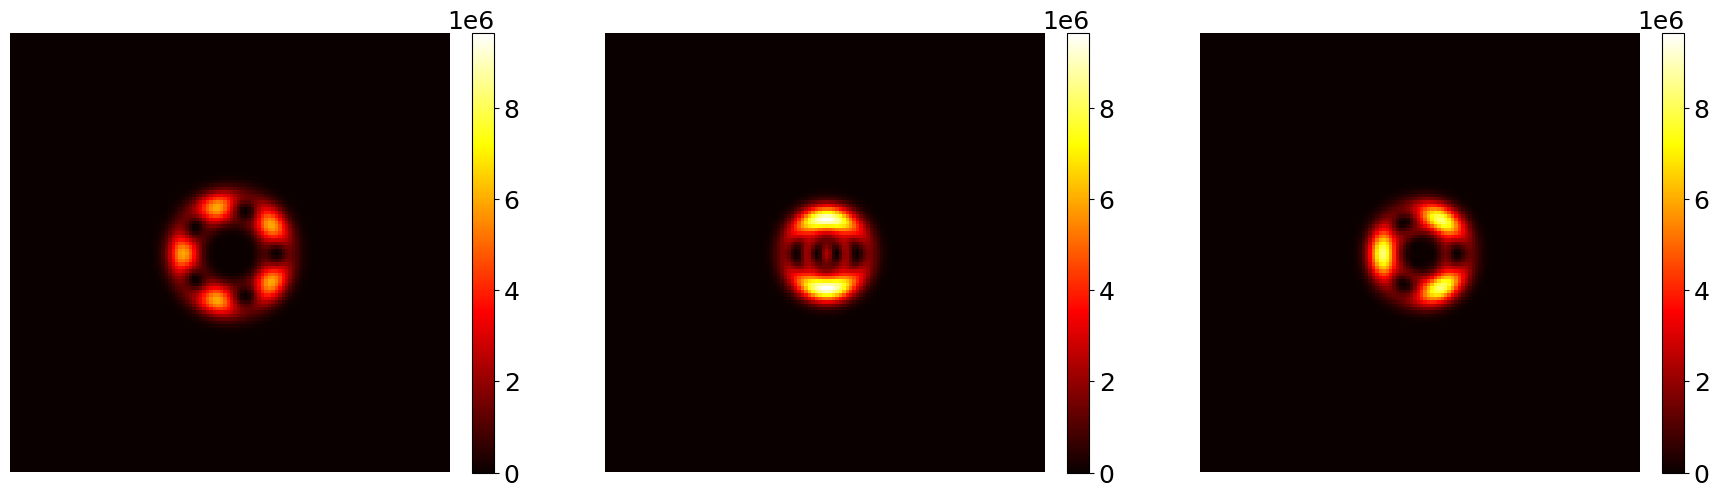

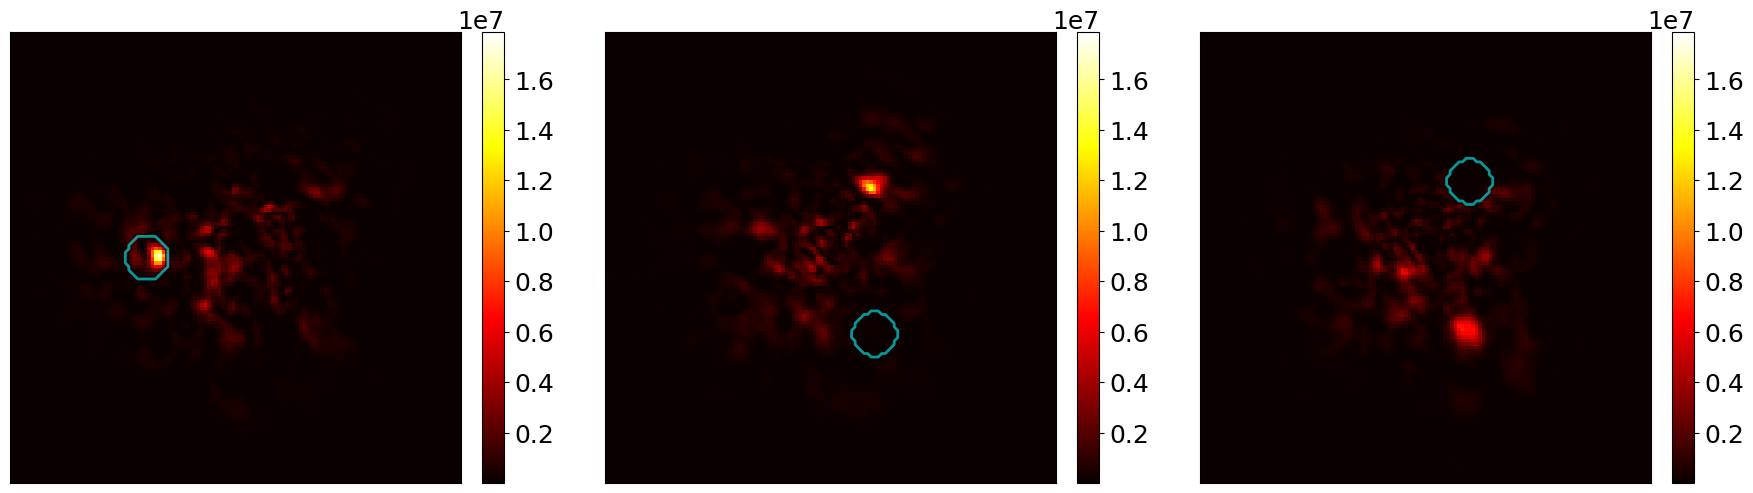

In [8]:
# Visualize all input and output fields in separate figures
# To save the plots, provide a save_path parameter (without _inputs/_outputs suffix):

roggy = visualize_input_output_fields(phase_maps, list_of_OAMs, save_path=f'inputs_outputs/april_7_2026/{instance_name}', colorbar_fontsize=18)

Compute the crosstalk matrix

In [9]:
sort_performance, crosstalk_matrix, _ , crosstalk_prob = compute_sorting_performance(phase_maps, list_of_OAMs)
print(crosstalk_matrix)
print(crosstalk_prob)

[0.12504627 0.12480236 0.13652853]
[[0.13493197 0.00418828 0.00569742]
 [0.00341933 0.13299926 0.00477758]
 [0.00422735 0.00676171 0.1475176 ]]
[[0.9317369  0.00418828 0.00569742]
 [0.00341933 0.9419467  0.00477758]
 [0.00422735 0.00676171 0.93067126]]


C:\Users\tjaouni\AppData\Local\Temp\ipykernel_16452\1561749023.py:133: ComplexWarning: Casting complex values to real discards the imaginary part
  sorting_performance[ii] = correct_chans - incorrect_chans
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_16452\1561749023.py:137: ComplexWarning: Casting complex values to real discards the imaginary part
  crosstalk_matrix[ii,ii] = detect_eff
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_16452\1561749023.py:141: ComplexWarning: Casting complex values to real discards the imaginary part
  crosstalk_prob[ii, ii] = sorting_probability
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_16452\1561749023.py:147: ComplexWarning: Casting complex values to real discards the imaginary part
  crosstalk_matrix[ii, ind] = crosstalk_eff
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_16452\1561749023.py:148: ComplexWarning: Casting complex values to real discards the imaginary part
  crosstalk_prob[ii, ind] = crosstalk_eff


Plot the crosstalk matrix

Crosstalk matrix saved to: cinque_hopf_tref_two_sc_new_ff_small_alpha.pdf


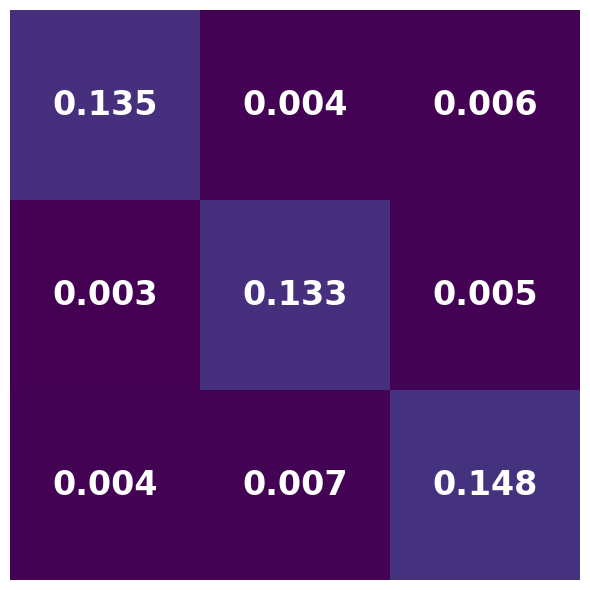

In [10]:
input_path = f"{instance_name}.pdf"

def plot_crosstalk_matrix_textless_square(
    crosstalk_matrix,
    labels=None,
    show_labels=False,
    annotate=True,
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
    figsize=(6, 6),
    save_path=None,
    dpi=300,
    annotation_fontsize=12,
    colorbar_fontsize=10,
    show_colorbar=True,
):
    """
    Plot a crosstalk matrix without axes and with a square-like aspect ratio.

    Parameters
    ----------
    crosstalk_matrix : np.ndarray
        Square matrix of crosstalk values.
    labels : list or None
        Optional labels for ticks. Used only if show_labels is True.
    show_labels : bool
        If True, shows ticks/labels; otherwise axes are removed.
    annotate : bool
        If True, draws the numeric values inside each cell.
    cmap : str
        Matplotlib colormap.
    vmin, vmax : float
        Color scale limits.
    figsize : tuple
        Figure size, default square.
    save_path : str or None
        If provided, saves the figure to this path (directories are created).
    dpi : int
        Resolution for saved figure.
    annotation_fontsize : int
        Font size for the annotation text inside cells (default: 12).
    colorbar_fontsize : int
        Font size for colorbar tick labels and offset text (default: 10).
    show_colorbar : bool
        If True, displays the colorbar; otherwise hides it (default: True).
    """
    import os
    import numpy as np
    import matplotlib.pyplot as plt

    num = crosstalk_matrix.shape[0]

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(crosstalk_matrix, vmin=vmin, vmax=vmax, cmap=cmap, aspect="equal")
    
    if show_colorbar:
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Intensity")
        cbar.ax.tick_params(labelsize=colorbar_fontsize)
        cbar.ax.yaxis.get_offset_text().set_fontsize(colorbar_fontsize)
        cbar.set_label("Intensity", fontsize=colorbar_fontsize)

    if annotate:
        for i in range(num):
            for j in range(num):
                text_color = "white" if crosstalk_matrix[i, j] < 0.5 else "black"
                ax.text(
                    j,
                    i,
                    f"{crosstalk_matrix[i, j]:.3f}",
                    ha="center",
                    va="center",
                    color=text_color,
                    fontsize=annotation_fontsize,
                    fontweight="bold",
                )

    if show_labels and labels is not None:
        ax.set_xticks(range(num))
        ax.set_yticks(range(num))
        ax.set_xticklabels(labels, fontsize=12)
        ax.set_yticklabels(labels, fontsize=12)
        ax.tick_params(bottom=False, left=False)
    else:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
        ax.axis("off")

    ax.set_title("")
    ax.set_xlabel("")
    ax.set_ylabel("")
    fig.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Crosstalk matrix saved to: {save_path}")

    return fig, ax

micky = plot_crosstalk_matrix_textless_square(crosstalk_matrix, annotate=True, save_path=input_path, annotation_fontsize=24, show_colorbar=False)

## Sorting Probability/Ability 

We also evaluate the so-called "sorting ability" of our holograms. For each mode n, the sorting probability is calculated as $P_{n} = \frac{I_{n}}{I_{n} + 
\sum_{m} \overline{I}_{m}}$ 



# Effect of Rotation on Hologram 

We can optionally apply rotations/translations onto the knotted field

In [11]:
# Rotates the incident knot by rot_phi

# rotate_mode: if None, rotate all modes; otherwise only rotate the specified mode index

def create_rotated_knots(rot_phi, rotate_mode=None):
    
    # Apply rotation operator on coords. Update: The rotation should be 
    # X_rot = np.cos(rot_phi)*X - np.sin(rot_phi)*Y
    # Y_rot = np.sin(rot_phi)*X + np.cos(rot_phi)*Y

    xx,yy=np.meshgrid(X ,Y)
    
    xx_rot = np.cos(rot_phi)*xx - np.sin(rot_phi)*yy
    yy_rot = np.sin(rot_phi)*xx + np.cos(rot_phi)*yy

    r_rot, phi_rot = cart2pol(xx_rot,yy_rot)

    ''' 
    Create the OAM beams that we need to sort 
    '''
    # Now create a list containing 'oamMode' objects 

    list_of_OAMs = []

    if(isKnot):
        for ii in range(len(knotType)):
            # Rotate only the selected mode (if rotate_mode is specified)
            if (rotate_mode is None) or (ii == rotate_mode):
                field_r = setKnotType(r_rot, phi_rot, w0, knotType[ii], shapeParams[ii])
            else:
                field_r = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
            list_of_OAMs.append(oamModes(field_r, output_chans[ii]))
    else:
        for ii in range(len(LG_modes)):
            if (rotate_mode is None) or (ii == rotate_mode):
                field_r = LG(r_rot, phi_rot, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k)
            else:
                field_r = LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k)
            list_of_OAMs.append(oamModes(field_r, output_chans[ii]))
    
    return list_of_OAMs


Iterating over the range of different angles, compute rotational effects. 

For three modes, remember that we have to account for two kinds of crosstalk.

In [34]:
rotate_angles = np.linspace(0, 2*np.pi, num=50)
mean_effs = []
mean_crosses_1 = []
mean_crosses_2 = []

mode=0

for angle in rotate_angles: 
    # Generate the rotated fields (rotate only the selected mode)
    list_of_rotated_OAMs = create_rotated_knots(angle, rotate_mode=mode)
    # Compute the crosstalk matrix 
    simulateLens = False
    sorting_performance, crosstalk_matrix, _, _= compute_sorting_performance(phase_maps, list_of_rotated_OAMs)

    mean_eff = crosstalk_matrix[mode,mode]
    mean_cross_1 = crosstalk_matrix[mode,(mode+1)%3]
    mean_cross_2 = crosstalk_matrix[mode,(mode+2)%3]
    
    mean_effs.append(mean_eff)
    mean_crosses_1.append(mean_cross_1)
    mean_crosses_2.append(mean_cross_2)


C:\Users\tjaouni\AppData\Local\Temp\ipykernel_16452\1561749023.py:133: ComplexWarning: Casting complex values to real discards the imaginary part
  sorting_performance[ii] = correct_chans - incorrect_chans
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_16452\1561749023.py:137: ComplexWarning: Casting complex values to real discards the imaginary part
  crosstalk_matrix[ii,ii] = detect_eff
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_16452\1561749023.py:141: ComplexWarning: Casting complex values to real discards the imaginary part
  crosstalk_prob[ii, ii] = sorting_probability
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_16452\1561749023.py:147: ComplexWarning: Casting complex values to real discards the imaginary part
  crosstalk_matrix[ii, ind] = crosstalk_eff
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_16452\1561749023.py:148: ComplexWarning: Casting complex values to real discards the imaginary part
  crosstalk_prob[ii, ind] = crosstalk_eff


[0.12504627 0.12480236 0.13652853]
[0.10650978 0.12480236 0.13652853]
[0.05748218 0.12480236 0.13652853]
[-0.00256411  0.12480236  0.13652853]
[-0.04978033  0.12480236  0.13652853]
[-0.06541349  0.12480236  0.13652853]
[-0.04325452  0.12480236  0.13652853]
[0.00789563 0.12480236 0.13652853]
[0.06772153 0.12480236 0.13652853]
[0.11246195 0.12480236 0.13652853]
[0.12434722 0.12480236 0.13652853]
[0.09865683 0.12480236 0.13652853]
[0.04559431 0.12480236 0.13652853]
[-0.01376536  0.12480236  0.13652853]
[-0.05584613  0.12480236  0.13652853]
[-0.06393467  0.12480236  0.13652853]
[-0.03481843  0.12480236  0.13652853]
[0.01993842 0.12480236 0.13652853]
[0.07858793 0.12480236 0.13652853]
[0.11783614 0.12480236 0.13652853]
[0.12209471 0.12480236 0.13652853]
[0.08967226 0.12480236 0.13652853]
[0.0334461  0.12480236 0.13652853]
[-0.02425227  0.12480236  0.13652853]
[-0.06050662  0.12480236  0.13652853]
[-0.06091772  0.12480236  0.13652853]
[-0.0253223   0.12480236  0.13652853]
[0.03214213 0.12480

Plot the rotation

In [35]:
Knot_Names = knotType
print(Knot_Names)

['Cinquefoil', 'Hopflink', 'Trefoil']


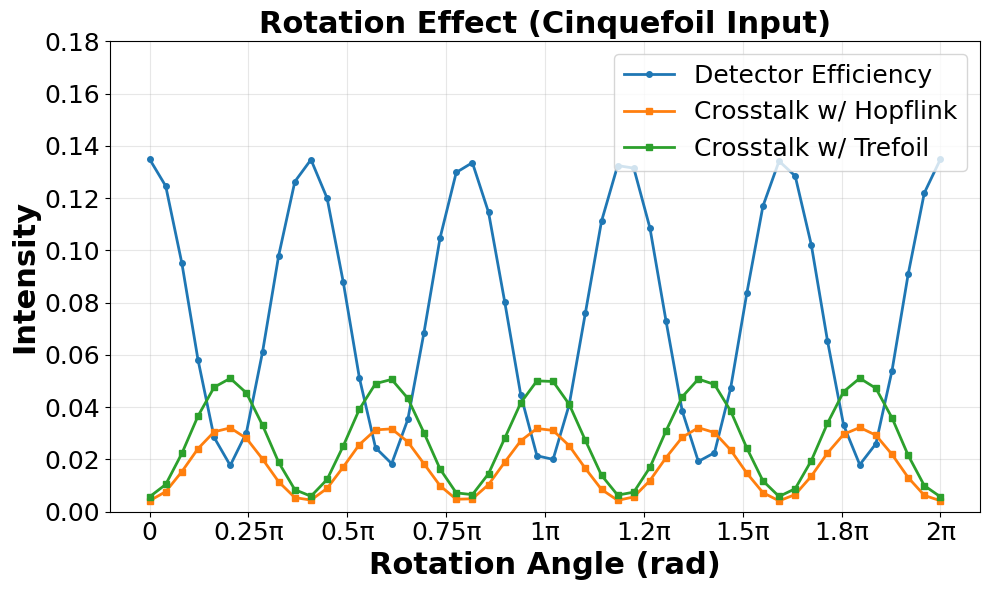

In [36]:
# Assign the crosstalk labels according to the mode number

cross_label_1 = knotType[(mode+1)%3]
cross_label_2 = knotType[(mode+2)%3]
mode_name = knotType[mode]

plt.figure(figsize=(10, 6))
plt.plot(rotate_angles, mean_effs, linewidth=2, label='Detector Efficiency', marker='o', markersize=4)
plt.plot(rotate_angles, mean_crosses_1, linewidth=2, label=f'Crosstalk w/ {cross_label_1}', marker='s', markersize=4)
plt.plot(rotate_angles, mean_crosses_2, linewidth=2, label=f'Crosstalk w/ {cross_label_2}', marker='s', markersize=4)
plt.xlabel('Rotation Angle (rad)', fontsize=22, fontweight='bold')
plt.ylabel('Intensity', fontsize=22, fontweight='bold')
plt.title(f'Rotation Effect ({mode_name} Input)', fontsize=22, fontweight='bold')
plt.legend(fontsize=18, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=18)

# Set fixed y-axis limits
plt.ylim(0, 0.18)

# Format x-axis with pi-style labels
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda val, pos: f'{val/np.pi:.2g}π' if val != 0 else '0'))
ax.xaxis.set_major_locator(plt.MultipleLocator(np.pi/4))

plt.tight_layout()
#plt.show()

plt.savefig(f'rotation_{mode_name}.pdf', bbox_inches='tight')

### Movie: rotating input knot (showing input + output)
Animate the sorter’s response while rotating the input knot; each frame shows the rotated input intensity (top row) and corresponding output modes (bottom row).

In [19]:
import os
import io
from PIL import Image


def generate_rotation_gif(rotation_angles, gif_path="plots/rotation_input_output.gif", duration=200, dpi=120, selected_mode=1):
    """
    Create a GIF while rotating the input knot. Each frame shows the rotated input
    intensity (top row) and the corresponding output modes (bottom row).

    rotation_angles: iterable of angles (radians) to sweep
    gif_path: output GIF path (directories are created if missing)
    duration: frame duration in ms
    dpi: resolution for saved frames
    selected_mode: which input mode index to rotate (others remain static)
    """
    os.makedirs(os.path.dirname(gif_path) or ".", exist_ok=True)

    frames = []
    effs = []
    crosses = []

    for angle in rotation_angles:
        list_of_rotated_OAMs = create_rotated_knots(angle, rotate_mode=selected_mode)
        #print(list_of_rotated_OAMs)

        d = len(list_of_rotated_OAMs)

        fig, axes = plt.subplots(2, d, figsize=(6 * d, 10))
        if d == 1:
            axes = np.array(axes).reshape(2, 1)

        for jj in range(d):
            # Input (rotated) field
            field_in = norm_field(list_of_rotated_OAMs[jj].oamBeam, h)
            input_intensity = np.abs(field_in) ** 2
            axes[0, jj].imshow(
                input_intensity,
                cmap="hot",
                extent=[-maxx / 2, maxx / 2, -maxx / 2, maxx / 2],
            )
            axes[0, jj].set_title(
                f"Input Mode {jj + 1} (θ={np.degrees(angle):.1f}°)",
                fontsize=12,
                fontweight="bold",
            )
            axes[0, jj].set_xlabel("x (m)", fontsize=10)
            axes[0, jj].set_ylabel("y (m)", fontsize=10)

            # Output field (same pipeline as visualize_input_output_fields)
            field_mod_1 = field_in * phase_maps[0]

            if multiPhase:
                field_after = field_mod_1
                for kk in range(1, len(phase_maps)):
                    field_after = propTF(field_after, maxx, la, z_o)
                    field_after = field_after * phase_maps[kk]
                final_field = propTF(field_after, maxx, la, z_o)
            else:
                if multiPhaseLens:
                    field_after = field_mod_1
                    for kk in range(1, num_phase_maps_near):
                        field_after = propTF(field_after, maxx, la, z_o)
                        field_after = field_after * phase_maps[kk]
                    field_lens = fftshift(fft2(field_after))
                elif simulateLens:
                    field_lens, _ = propFF(field_mod_1, maxx, la, fourier_lens)
                else:
                    field_lens = fftshift(fft2(field_mod_1))

                if num_phase_maps_far == 0:
                    final_field = field_lens
                else:
                    field_mod_2 = field_lens * phase_maps[num_phase_maps_near]
                    if multiPhaseLens:
                        field_after_2 = field_mod_2
                        for ll in range(1 + num_phase_maps_near, num_of_phase_maps):
                            field_after_2 = propTF(field_after_2, maxx, la, z_o)
                            field_after_2 = field_after_2 * phase_maps[ll]
                        field_lens_2 = ifft2(ifftshift(field_after_2))
                    elif simulateLens:
                        field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
                    else:
                        field_lens_2 = ifft2(ifftshift(field_mod_2))
                    final_field = field_lens_2

            final_field = norm_field(final_field, h)
            output_intensity = np.abs(final_field) ** 2
            im = axes[1, jj].imshow(
                output_intensity,
                cmap="hot",
                extent=[-maxx / 2, maxx / 2, -maxx / 2, maxx / 2],
            )
            axes[1, jj].set_title(
                f"Output Mode {jj + 1} (θ={np.degrees(angle):.1f}°)",
                fontsize=12,
                fontweight="bold",
            )
            axes[1, jj].set_xlabel("x (m)", fontsize=10)
            axes[1, jj].set_ylabel("y (m)", fontsize=10)
            fig.colorbar(im, ax=axes[1, jj], fraction=0.046, pad=0.04)

            if jj < len(output_chans):
                axes[1, jj].contour(
                    output_chans[jj],
                    levels=[0.5],
                    colors="cyan",
                    linewidths=2,
                    extent=[-maxx / 2, maxx / 2, -maxx / 2, maxx / 2],
                    alpha=0.6,
                )

        fig.tight_layout()

        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
        buf.seek(0)
        frames.append(Image.open(buf).copy())
        buf.close()
        plt.close(fig)

        sorting_performance, crosstalk_matrix, _ = compute_sorting_performance(
            phase_maps, list_of_rotated_OAMs
        )
        effs.append(crosstalk_matrix[selected_mode, selected_mode])
        crosses.append(crosstalk_matrix[selected_mode, (selected_mode + 1) % 2])

    frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=duration, loop=0)
    print(f"GIF saved to: {gif_path}")

    return np.array(effs), np.array(crosses)


In [20]:
mode = 0

# Generate GIF while sweeping rotation angles (input + output shown)
rotation_angles_for_gif = np.linspace(0, 2 * np.pi, 50)
effs_rot_movie, cross_rot_movie = generate_rotation_gif(
    rotation_angles_for_gif,
    gif_path=f"plots/rotation_input_output_{mode}.gif",
    duration=200,
    dpi=120,
    selected_mode=mode,
)

# Quick visualization of the metrics captured alongside the movie
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(rotation_angles_for_gif, effs_rot_movie, marker="o", color="blue")
ax1.set_title("Detector Efficiency vs rotation angle (movie frames)")
ax1.set_xlabel("Rotation angle (rad)")
ax1.set_ylabel("Detector Efficiency")
ax1.grid(True, alpha=0.3)

ax2.plot(rotation_angles_for_gif, cross_rot_movie, marker="s", color="red")
ax2.set_title("Crosstalk vs rotation angle (movie frames)")
ax2.set_xlabel("Rotation angle (rad)")
ax2.set_ylabel("Crosstalk")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


c:\Users\tjaouni\Desktop\Knot Sorter Project\KnotSorter\venv\Lib\site-packages\matplotlib\contour.py:1364: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = z.max().astype(float)
c:\Users\tjaouni\Desktop\Knot Sorter Project\KnotSorter\venv\Lib\site-packages\matplotlib\contour.py:1365: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = z.min().astype(float)
c:\Users\tjaouni\Desktop\Knot Sorter Project\KnotSorter\venv\Lib\site-packages\numpy\ma\core.py:2885: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_39476\1561749023.py:133: ComplexWarning: Casting complex values to real discards the imaginary part
  sorting_performance[ii] = correct_chans - incorrect_chans
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_39476\1561749023.py:137: ComplexWarning: Casting complex values to real discards the i

[0.12504627 0.12480236 0.13652853]


ValueError: too many values to unpack (expected 3, got 4)

# Effect of Translation on Field Performance

In [39]:
# Translate only the selected mode; others stay fixed
def create_translated_knots(x_shift, y_shift, translate_mode=None):
    """
    Generate translated knots. If translate_mode is provided, only that input mode is translated;
    others remain at the original position.
    """
    xx, yy = np.meshgrid(X, Y)

    xx_t = xx - x_shift
    yy_t = yy - y_shift

    r_t, phi_t = cart2pol(xx_t, yy_t)

    list_of_OAMs = []

    if isKnot:
        for ii in range(len(knotType)):
            if (translate_mode is None) or (ii == translate_mode):
                field_t = setKnotType(r_t, phi_t, w0, knotType[ii], shapeParams[ii])
            else:
                field_t = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
            list_of_OAMs.append(oamModes(field_t, output_chans[ii]))
    else:
        for ii in range(len(LG_modes)):
            if (translate_mode is None) or (ii == translate_mode):
                field_t = LG(r_t, phi_t, LG_modes[ii][0], LG_modes[ii][1], w0, h, 0, k)
            else:
                field_t = LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0, h, 0, k)
            list_of_OAMs.append(oamModes(field_t, output_chans[ii]))

    return list_of_OAMs


In [76]:
x_translate = np.linspace(-0.1*mm, +0.1*mm, num=50)
y_translate = np.linspace(-0.1*mm, +0.1*mm, num=50)

effs = []
crosses_1 = []
crosses_2 = []

effs_mode = []
cross_1_mode = []
cross_2_mode = []

mode=0

# How does the detector efficency and crosstalk change with the Trefoil? with the Cinquefoil? 

for x_trans in x_translate:
    eff_row = []
    cross_1_row = []
    cross_2_row = []
    
    for y_trans in y_translate:
        
        # Generated the translated fields (translate only the selected mode)
        list_of_translated_OAMs = create_translated_knots(x_trans, y_trans, translate_mode=mode)
        
        # Compute the crosstalk matrix
        sorting_performance, crosstalk_matrix, _, _ = compute_sorting_performance(phase_maps, list_of_translated_OAMs)
        
        # Extract the desired crosstalk/detector efficency 
        eff_row.append(crosstalk_matrix[mode,mode])
        cross_1_row.append(crosstalk_matrix[mode, (mode+1)%3])
        cross_2_row.append(crosstalk_matrix[mode, (mode+2)%3])
    
    effs.append(eff_row)
    crosses_1.append(cross_1_row)
    crosses_2.append(cross_2_row)


C:\Users\tjaouni\AppData\Local\Temp\ipykernel_16452\1561749023.py:133: ComplexWarning: Casting complex values to real discards the imaginary part
  sorting_performance[ii] = correct_chans - incorrect_chans
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_16452\1561749023.py:137: ComplexWarning: Casting complex values to real discards the imaginary part
  crosstalk_matrix[ii,ii] = detect_eff
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_16452\1561749023.py:141: ComplexWarning: Casting complex values to real discards the imaginary part
  crosstalk_prob[ii, ii] = sorting_probability
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_16452\1561749023.py:147: ComplexWarning: Casting complex values to real discards the imaginary part
  crosstalk_matrix[ii, ind] = crosstalk_eff
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_16452\1561749023.py:148: ComplexWarning: Casting complex values to real discards the imaginary part
  crosstalk_prob[ii, ind] = crosstalk_eff


[0.02050957 0.12480236 0.13652853]
[0.02240356 0.12480236 0.13652853]
[0.0242639  0.12480236 0.13652853]
[0.02609044 0.12480236 0.13652853]
[0.02788383 0.12480236 0.13652853]
[0.02964533 0.12480236 0.13652853]
[0.03137649 0.12480236 0.13652853]
[0.03307879 0.12480236 0.13652853]
[0.03475328 0.12480236 0.13652853]
[0.03640024 0.12480236 0.13652853]
[0.03801877 0.12480236 0.13652853]
[0.03960654 0.12480236 0.13652853]
[0.04115948 0.12480236 0.13652853]
[0.04267161 0.12480236 0.13652853]
[0.04413491 0.12480236 0.13652853]
[0.04553934 0.12480236 0.13652853]
[0.04687286 0.12480236 0.13652853]
[0.04812166 0.12480236 0.13652853]
[0.0492704  0.12480236 0.13652853]
[0.05030257 0.12480236 0.13652853]
[0.05120091 0.12480236 0.13652853]
[0.05194794 0.12480236 0.13652853]
[0.05252641 0.12480236 0.13652853]
[0.05291993 0.12480236 0.13652853]
[0.05311345 0.12480236 0.13652853]
[0.05309384 0.12480236 0.13652853]
[0.0528503  0.12480236 0.13652853]
[0.05237485 0.12480236 0.13652853]
[0.05166261 0.124802

### Movie: translating the selected input knot (input + output)

In [55]:
import os
import io
from PIL import Image

def generate_translation_gif(translation_pairs, gif_path="plots/translation_input_output.gif", duration=200, dpi=120, selected_mode=1):
    """
    Create a GIF while translating the selected input knot. Each frame shows the translated
    input intensity (top row) and the corresponding output modes (bottom row).

    translation_pairs: iterable of (x_shift, y_shift) tuples in meters
    gif_path: output GIF path (directories are created if missing)
    duration: frame duration in ms
    dpi: resolution for saved frames
    selected_mode: which input mode index to translate (others remain static)
    """
    os.makedirs(os.path.dirname(gif_path) or ".", exist_ok=True)

    frames = []
    effs = []
    crosses = []

    for x_shift, y_shift in translation_pairs:
        list_of_translated_OAMs = create_translated_knots(x_shift, y_shift, translate_mode=selected_mode)
        d = len(list_of_translated_OAMs)

        fig, axes = plt.subplots(2, d, figsize=(6 * d, 10))
        if d == 1:
            axes = np.array(axes).reshape(2, 1)

        for jj in range(d):
            # Input (translated) field
            field_in = norm_field(list_of_translated_OAMs[jj].oamBeam, h)
            input_intensity = np.abs(field_in) ** 2
            axes[0, jj].imshow(
                input_intensity,
                cmap="hot",
                extent=[-maxx / 2, maxx / 2, -maxx / 2, maxx / 2],
            )
            axes[0, jj].set_title(
                f"Input Mode {jj + 1} (Δx={x_shift/um:.1f} μm, Δy={y_shift/um:.1f} μm)",
                fontsize=12,
                fontweight="bold",
            )
            axes[0, jj].set_xlabel("x (m)", fontsize=10)
            axes[0, jj].set_ylabel("y (m)", fontsize=10)

            # Output field (same pipeline as visualize_input_output_fields)
            field_mod_1 = field_in * phase_maps[0]

            if multiPhase:
                field_after = field_mod_1
                for kk in range(1, len(phase_maps)):
                    field_after = propTF(field_after, maxx, la, z_o)
                    field_after = field_after * phase_maps[kk]
                final_field = propTF(field_after, maxx, la, z_o)
            else:
                if multiPhaseLens:
                    field_after = field_mod_1
                    for kk in range(1, num_phase_maps_near):
                        field_after = propTF(field_after, maxx, la, z_o)
                        field_after = field_after * phase_maps[kk]
                    field_lens = fftshift(fft2(field_after))
                elif simulateLens:
                    field_lens, _ = propFF(field_mod_1, maxx, la, fourier_lens)
                else:
                    field_lens = fftshift(fft2(field_mod_1))

                if num_phase_maps_far == 0:
                    final_field = field_lens
                else:
                    field_mod_2 = field_lens * phase_maps[num_phase_maps_near]
                    if multiPhaseLens:
                        field_after_2 = field_mod_2
                        for ll in range(1 + num_phase_maps_near, num_of_phase_maps):
                            field_after_2 = propTF(field_after_2, maxx, la, z_o)
                            field_after_2 = field_after_2 * phase_maps[ll]
                        field_lens_2 = ifft2(ifftshift(field_after_2))
                    elif simulateLens:
                        field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
                    else:
                        field_lens_2 = ifft2(ifftshift(field_mod_2))
                    final_field = field_lens_2

            final_field = norm_field(final_field, h)
            output_intensity = np.abs(final_field) ** 2
            im = axes[1, jj].imshow(
                output_intensity,
                cmap="hot",
                extent=[-maxx / 2, maxx / 2, -maxx / 2, maxx / 2],
            )
            axes[1, jj].set_title(
                f"Output Mode {jj + 1} (Δx={x_shift/um:.1f} μm, Δy={y_shift/um:.1f} μm)",
                fontsize=12,
                fontweight="bold",
            )
            axes[1, jj].set_xlabel("x (m)", fontsize=10)
            axes[1, jj].set_ylabel("y (m)", fontsize=10)
            fig.colorbar(im, ax=axes[1, jj], fraction=0.046, pad=0.04)

            if jj < len(output_chans):
                axes[1, jj].contour(
                    output_chans[jj],
                    levels=[0.5],
                    colors="cyan",
                    linewidths=2,
                    extent=[-maxx / 2, maxx / 2, -maxx / 2, maxx / 2],
                    alpha=0.6,
                )

        fig.tight_layout()

        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
        buf.seek(0)
        frames.append(Image.open(buf).copy())
        buf.close()
        plt.close(fig)

        sorting_performance, crosstalk_matrix, _ = compute_sorting_performance(
            phase_maps, list_of_translated_OAMs
        )
        effs.append(crosstalk_matrix[selected_mode, selected_mode])
        crosses.append(crosstalk_matrix[selected_mode, (selected_mode + 1) % 2])

    frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=duration, loop=0)
    print(f"GIF saved to: {gif_path}")

    return np.array(effs), np.array(crosses)


In [42]:
# Generate GIF while sweeping translations of the selected mode (input + output shown)
mode = 0
translation_pairs = [(x, 0.0) for x in np.linspace(-0.1*mm, +0.1*mm, 24)]

effs_trans_movie, cross_trans_movie = generate_translation_gif(
    translation_pairs,
    gif_path=f"plots/translation_input_output_{mode}.gif",
    duration=200,
    dpi=120,
    selected_mode=mode,
)

# Quick visualization of the metrics captured alongside the movie
x_shifts = np.array([p[0] for p in translation_pairs])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(x_shifts, effs_trans_movie, marker="o", color="blue")
ax1.set_title("Detector Efficiency vs translation (movie frames)")
ax1.set_xlabel("Δx (m)")
ax1.set_ylabel("Detector Efficiency")
ax1.grid(True, alpha=0.3)

ax2.plot(x_shifts, cross_trans_movie, marker="s", color="red")
ax2.set_title("Crosstalk vs translation (movie frames)")
ax2.set_xlabel("Δx (m)")
ax2.set_ylabel("Crosstalk")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


c:\Users\tjaouni\Desktop\Knot Sorter Project\KnotSorter\venv\Lib\site-packages\matplotlib\contour.py:1364: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = z.max().astype(float)
c:\Users\tjaouni\Desktop\Knot Sorter Project\KnotSorter\venv\Lib\site-packages\matplotlib\contour.py:1365: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = z.min().astype(float)
c:\Users\tjaouni\Desktop\Knot Sorter Project\KnotSorter\venv\Lib\site-packages\numpy\ma\core.py:2885: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_16452\1561749023.py:133: ComplexWarning: Casting complex values to real discards the imaginary part
  sorting_performance[ii] = correct_chans - incorrect_chans
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_16452\1561749023.py:137: ComplexWarning: Casting complex values to real discards the i

[0.05313102 0.12480236 0.13652853]


ValueError: too many values to unpack (expected 3, got 4)

Make a cool 3D plot because everyone likes 3D plots boy howdy

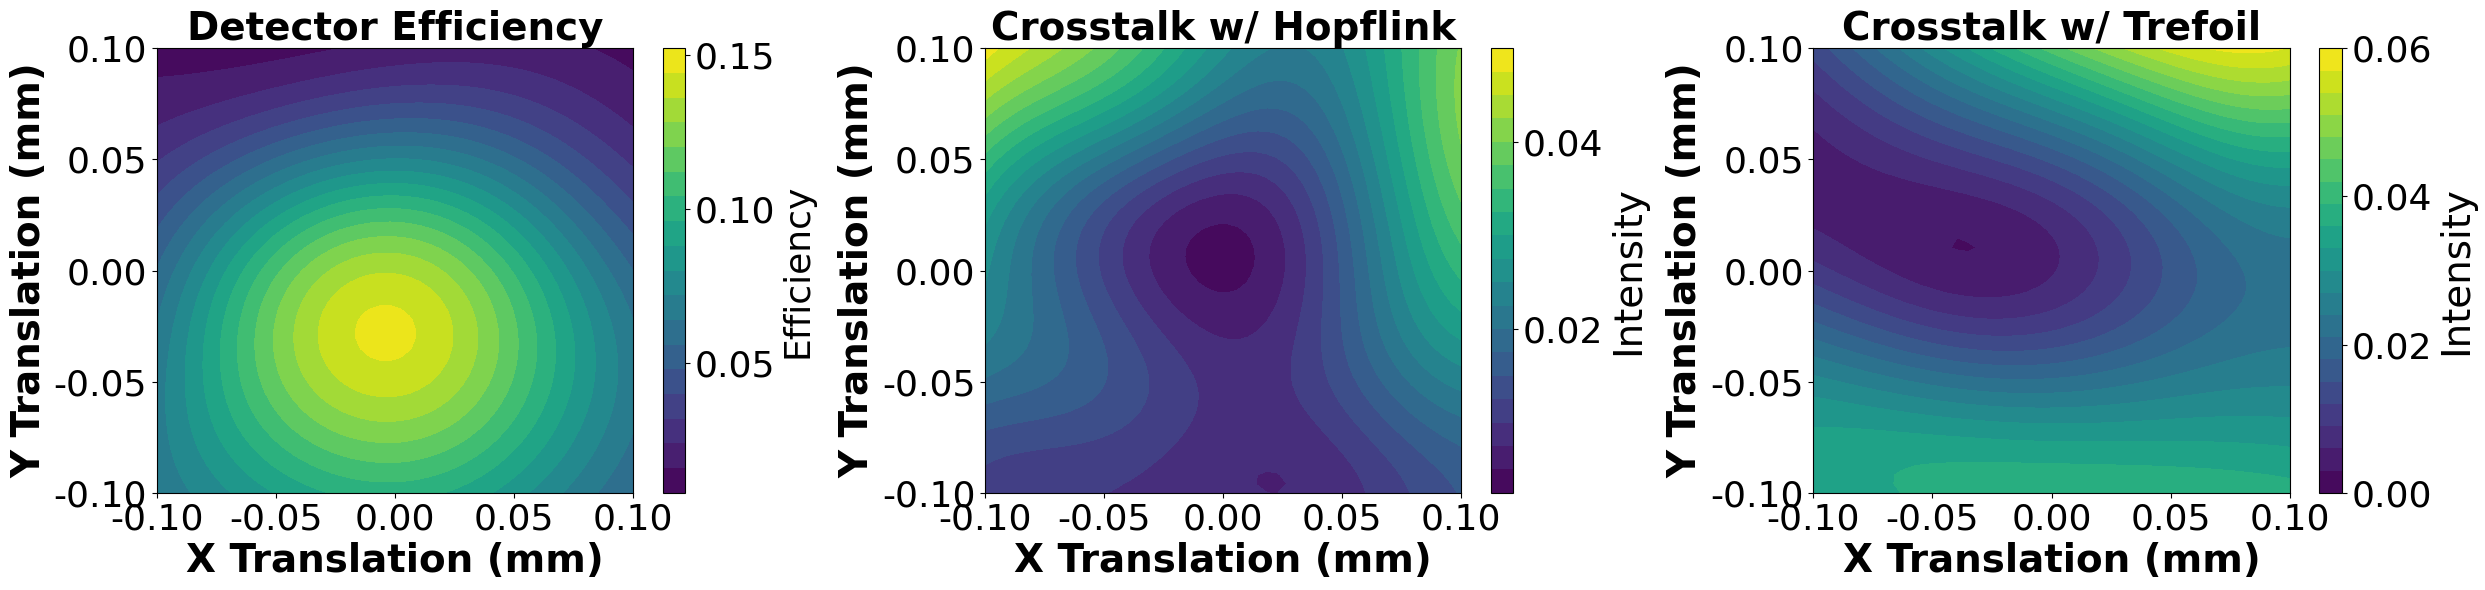

In [77]:

# Create meshgrid for contour plots
X_trans, Y_trans = np.meshgrid(x_translate, y_translate)
mode_name = knotType[mode]

# Create 3x1 subplot layout with contour plots (space-efficient alternative to 3D)
fig, axes = plt.subplots(1, 3, figsize=(25, 6))

# Detector Efficiency
im1 = axes[0].contourf(X_trans/mm, Y_trans/mm, np.array(effs), levels=20, cmap='viridis')
axes[0].set_xlabel('X Translation (mm)', fontweight='bold', fontsize=28)
axes[0].set_ylabel('Y Translation (mm)', fontweight='bold', fontsize=28)
axes[0].set_title(f'Detector Efficiency', fontweight='bold', fontsize=28)
# Reduce number of ticks and format with fewer decimal places
axes[0].locator_params(axis='x', nbins=5)
axes[0].locator_params(axis='y', nbins=5)
axes[0].ticklabel_format(style='plain', axis='both', useOffset=False)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{y:.2f}'))
axes[0].tick_params(axis='both', which='major', labelsize=26)  # Set tick label size
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Efficiency', fontsize=26)
cbar1.ax.tick_params(labelsize=26)  # Colorbar tick size
cbar1.locator = plt.MaxNLocator(nbins=3)
cbar1.update_ticks()

# Crosstalk 1
im2 = axes[1].contourf(X_trans/mm, Y_trans/mm, np.array(crosses_1), levels=20, cmap='viridis')
axes[1].set_xlabel('X Translation (mm)', fontweight='bold', fontsize=28)
axes[1].set_ylabel('Y Translation (mm)', fontweight='bold', fontsize=28)
axes[1].set_title(f'Crosstalk w/ {knotType[(mode+1)%len(knotType)]}', fontweight='bold', fontsize=28)
# Reduce number of ticks and format with fewer decimal places
axes[1].locator_params(axis='x', nbins=5)
axes[1].locator_params(axis='y', nbins=5)
axes[1].ticklabel_format(style='plain', axis='both', useOffset=False)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{y:.2f}'))
axes[1].tick_params(axis='both', which='major', labelsize=26)  # Set tick label size
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('Intensity', fontsize=28)
cbar2.ax.tick_params(labelsize=26)  # Colorbar tick size
cbar2.locator = plt.MaxNLocator(nbins=3)
cbar2.update_ticks()

# Third metric (second crosstalk)
total_metric = np.array(crosses_2)
im3 = axes[2].contourf(X_trans/mm, Y_trans/mm, total_metric, levels=20, cmap='viridis')
axes[2].set_xlabel('X Translation (mm)', fontweight='bold', fontsize=28)
axes[2].set_ylabel('Y Translation (mm)', fontweight='bold', fontsize=28)
axes[2].set_title(f'Crosstalk w/ {knotType[(mode+2)%len(knotType)]}', fontweight='bold', fontsize=28)
# Reduce number of ticks and format with fewer decimal places
axes[2].locator_params(axis='x', nbins=5)
axes[2].locator_params(axis='y', nbins=5)
axes[2].ticklabel_format(style='plain', axis='both', useOffset=False)
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{y:.2f}'))
axes[2].tick_params(axis='both', which='major', labelsize=26)  # Set tick label size
cbar3 = plt.colorbar(im3, ax=axes[2])
cbar3.set_label('Intensity', fontsize=28)
cbar3.ax.tick_params(labelsize=26)  # Colorbar tick size
cbar3.locator = plt.MaxNLocator(nbins=3)
cbar3.update_ticks()

plt.tight_layout()

plt.savefig(f'translation_{mode_name}.pdf', bbox_inches='tight')


# Effects of Aberrations on Optical Knots

We investigate the effects of sorting aberrated knots. We apply classes of aberrations on the transverse field and investigate how the performance of our sorter changes.

Functions to implement the aberrations (here, they are modelled as Zernike polynomials). For a start, we can check Trefoil, Quadrafoil, Coma, and Astigmatism? 

Some details

Astigmatism (n=2, m=2)
Coma (n=3, m=1)
Trefoil (n=3, m=3)
Quadrafoil (n=4, m=4)

We might need to play with the aperature. 

In [78]:
import math

### For Aberrations ###

# Coeffcients and powers or the radial Polynomials 
# m,n - indexes of the Zernike Polynomials 

def RR(m,n):
    nm=n-m
    coeff=[]
    powr=[]
    if (n-m)%2==0:
        for kk in range(0,int((n-m)/2+1)):
            aa=((-1)**kk*math.factorial(n-kk))/(math.factorial(kk)*math.factorial(int((n+m)/2)-kk)*math.factorial(int((n-m)/2-kk)))
            bb=n-2*kk
            coeff.append(aa)
            powr.append(bb)
    else: 
        coeff.append(0)
        powr.append(0)
    return([coeff,powr])

# Construction of the Normalized Zernike polynomials
# RHO - Radial coordinate
# PHi - Azimuthal coordinate 
# m,n - indexes of the Zernike Polynomials 

def Zernike(RHO,PHI,m,n):
    ZR=np.zeros(RHO.shape); 
    rn=RR(np.abs(m),n)
    for ii in range(len(rn[0])):
        ZR=ZR+rn[0][ii]*RHO**rn[1][ii]
    if m>=0: 
        Z=ZR*np.cos(np.abs(m)*PHI)
    else:
        Z=ZR*np.sin(np.abs(m)*PHI)
    M=(RHO<=1)
    P=Z*M
    return(P)

# Computes an arbitrary phase modulation from a sum of Zernike modes
# m_n_dict - Dictionary of Zernike modes of the form {(m, n): coefficient}
# RHO - Radial coordinate array
# PHI - Azimuthal coordinate array

def ZernikeSuper(m_n_dict, RHO, PHI):
    # Initialize the phase modulation array with zeros
    phase = np.zeros(RHO.shape)
    
    # Iterate over the dictionary and add each Zernike mode weighted by its coefficient
    for (m, n), coeff in m_n_dict.items():
        phase += coeff * Zernike(RHO, PHI, m, n)

    return phase

# Performs a decomposition from the Noll index (j) to the Zernike modes (n, m)
# j - Noll index

def noll_to_nm(j):
    n = int(math.ceil((-3 + math.sqrt(1 + 8*j)) / 2))
    p = j - n*(n+1)//2
    if n % 2 == 0:
        m = 2 * (p // 2)
    else:
        m = 2 * ((p + 1) // 2) - 1

    if j % 2 == 0:
        m = -m
    return n, m


Generate aberrated knots. We iterate over multiple strengths

In [79]:
def create_aberrated_knots(m_n, gamma, aperature):

    '''
    generates aberrated knots 

    m_n -- tuple indicating the Zernike mode indices (m, n)
    gamma -- strength of the Zernike modes
    aperature -- aperature size of the aberration
    '''

    list_of_OAMs = []
    m, n = m_n
    P = Zernike(r/aperature, phi, m, n)

    if(isKnot):
        for ii in range(len(knotType)):
            field = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
            aber_field = field*np.exp(1j*np.pi*gamma*P)
            list_of_OAMs.append(oamModes(aber_field, output_chans[ii]))
    else:
        for ii in range(len(LG_modes)):
            field = LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k)
            aber_field = field*np.exp(1j*np.pi*gamma*P)
            list_of_OAMs.append(oamModes(LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k), output_chans[ii]))
    
    return list_of_OAMs


### Export Phase Patterns to CSV

In [ ]:
import pandas as pd
import os

def export_knot_phase_to_csv(knot_type, shape_params, m_n=None, gamma=0.0, aperature=None, 
                               output_dir='phase_exports', filename_prefix='knot_phase'):
    
    """
    Export the phase pattern of a knotted beam to CSV files.
    
    Parameters:
    -----------
    knot_type : str
        Type of knot (e.g., 'trefoil', 'cinquefoil', 'hopflink')
    shape_params : list
        Shape parameters for the knot
    m_n : tuple, optional
        Zernike mode indices (m, n) for aberration. If None, no aberration applied.
    gamma : float
        Aberration strength (default: 0.0 for no aberration)
    aperature : float, optional
        Aperture size for aberration. If None, uses 4*w0
    output_dir : str
        Directory to save CSV files
    filename_prefix : str
        Prefix for output filenames
    
    Returns:
    --------
    dict : Dictionary with paths to saved CSV files
    """
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Set default aperture if not provided
    if aperature is None:
        aperature = 4.0 * w0
    
    # Generate the pristine (non-aberrated) knot field
    print(knot_type)
    pristine_field = setKnotType(r, phi, w0, knot_type, shape_params)
    pristine_phase = np.angle(pristine_field)
    
    # Export pristine knot phase
    pristine_filename = f'{filename_prefix}_{knot_type}_pristine.csv'
    pristine_path = os.path.join(output_dir, pristine_filename)
    pd.DataFrame(pristine_phase).to_csv(pristine_path, index=False, header=False)
    
    result = {
        'pristine': pristine_path,
        'knot_type': knot_type,
        'gamma': gamma
    }
    
    # If aberration is requested
    if m_n is not None and gamma > 0:
        m, n = m_n
        P = Zernike(r/aperature, phi, m, n)
        
        # Apply aberration
        aberrated_field = pristine_field * np.exp(1j * np.pi * gamma * P)
        aberrated_phase = np.angle(aberrated_field)
        
        # Export aberrated knot phase
        aberrated_filename = f'{filename_prefix}_{knot_type}_aberrated_m{m}_n{n}_gamma{gamma:.2f}.csv'
        aberrated_path = os.path.join(output_dir, aberrated_filename)
        pd.DataFrame(aberrated_phase).to_csv(aberrated_path, index=False, header=False)
        
        result['aberrated'] = aberrated_path
        result['m_n'] = m_n
    
    print(f"✓ Pristine phase exported to: {pristine_path}")
    if 'aberrated' in result:
        print(f"✓ Aberrated phase exported to: {result['aberrated']}")
    
    return result

#### Example: Export phase patterns for different knots and aberrations

In [44]:
# Example 1: Export a trefoil knot without aberration
result1 = export_knot_phase_to_csv(
    knot_type='Trefoil',
    shape_params=[0.88, 0.88, 1.0],
    output_dir='phase_exports',
    filename_prefix='example'
)


# Example 2: Export a trefoil knot with secondary astigmatism aberration
result2 = export_knot_phase_to_csv(
    knot_type='Cinquefoil',
    shape_params=[0.88, 0.88, 1.0],
    m_n=(3, 3),  # Trefoil
    gamma=1.0,
    aperature=4.0*w0,
    output_dir='phase_exports',
    filename_prefix='example'
)

# Example 3: Export a cinquefoil knot with coma aberration
result3 = export_knot_phase_to_csv(
    knot_type='Cinquefoil',
    shape_params=[2.0, 2.0, 1.0],
    m_n=(1, 3),  # Coma
    gamma=0.75,
    aperature=8.0*w0,
    output_dir='phase_exports',
    filename_prefix='example'
)

print("\n--- Export Summary ---")
print(f"Total CSV files created: {1 + len([r for r in [result1, result2, result3] if 'aberrated' in r])}")

Trefoil
✓ Pristine phase exported to: phase_exports\example_Trefoil_pristine.csv
Cinquefoil
✓ Pristine phase exported to: phase_exports\example_Cinquefoil_pristine.csv
✓ Aberrated phase exported to: phase_exports\example_Cinquefoil_aberrated_m3_n3_gamma1.00.csv
Cinquefoil
✓ Pristine phase exported to: phase_exports\example_Cinquefoil_pristine.csv
✓ Aberrated phase exported to: phase_exports\example_Cinquefoil_aberrated_m1_n3_gamma0.75.csv

--- Export Summary ---
Total CSV files created: 3


#### Visualize exported phase patterns (optional)

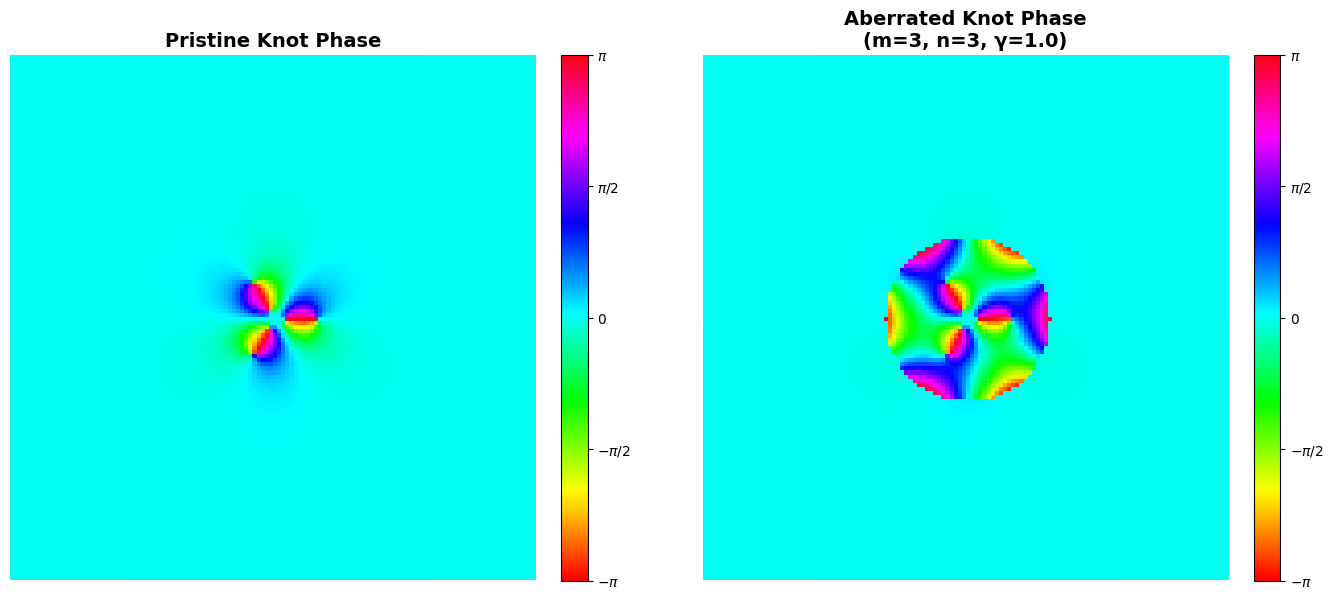


✓ Visualization complete!


In [38]:
# Visualize the exported phase patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Load and plot pristine phase
pristine_phase_data = pd.read_csv(result2['pristine'], header=None).values
im1 = axes[0].imshow(pristine_phase_data, cmap='hsv', vmin=-np.pi, vmax=np.pi)
axes[0].set_title('Pristine Knot Phase', fontsize=14, fontweight='bold')
axes[0].axis('off')
cbar1 = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
cbar1.set_ticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])

# Load and plot aberrated phase
if 'aberrated' in result2:
    aberrated_phase_data = pd.read_csv(result2['aberrated'], header=None).values
    im2 = axes[1].imshow(aberrated_phase_data, cmap='hsv', vmin=-np.pi, vmax=np.pi)
    axes[1].set_title(f'Aberrated Knot Phase\n(m={result2["m_n"][0]}, n={result2["m_n"][1]}, γ={result2["gamma"]})', 
                     fontsize=14, fontweight='bold')
    axes[1].axis('off')
    cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    cbar2.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    cbar2.set_ticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])

plt.tight_layout()
plt.show()

print(f"\n✓ Visualization complete!")

#### Clean phase plots (no axes, no colorbars)

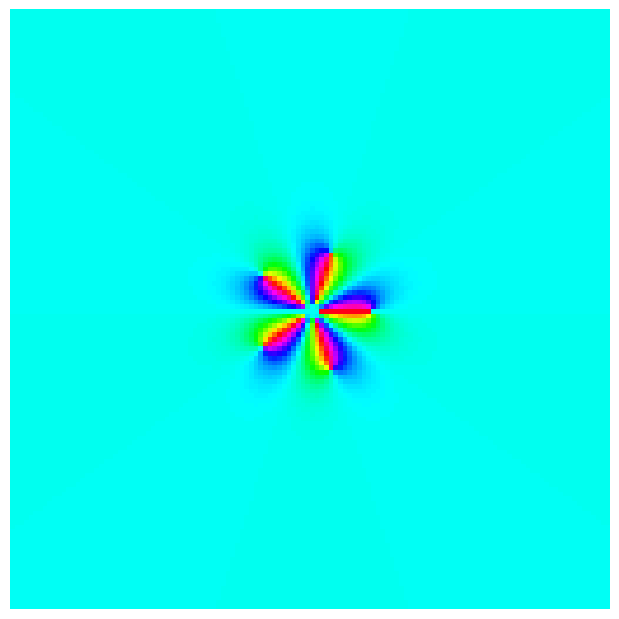

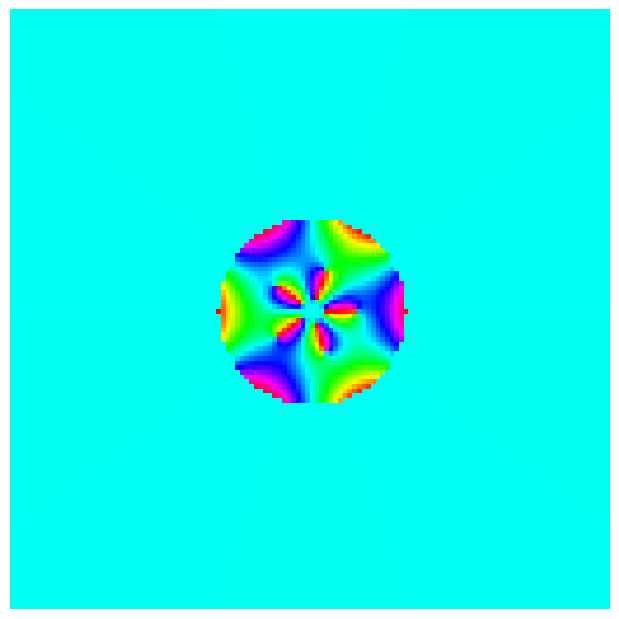

In [45]:
# Plot pristine knot phase (clean, no axes, no colorbar)
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
pristine_phase_data = pd.read_csv(result2['pristine'], header=None).values
ax.imshow(pristine_phase_data, cmap='hsv', vmin=-np.pi, vmax=np.pi)
ax.axis('off')
plt.tight_layout(pad=0)
plt.show()

# Plot aberrated knot phase (clean, no axes, no colorbar)
if 'aberrated' in result2:
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    aberrated_phase_data = pd.read_csv(result2['aberrated'], header=None).values
    ax.imshow(aberrated_phase_data, cmap='hsv', vmin=-np.pi, vmax=np.pi)
    ax.axis('off')
    plt.tight_layout(pad=0)
    plt.show()

#### Export all knots in your current configuration

In [ ]:
# Export phase patterns for all knots in your current configuration
# This uses the knotType and shapeParams variables from your config

if isKnot:
    print(f"Exporting phase patterns for {len(knotType)} knots...\n")
    
    for idx, (knot, params) in enumerate(zip(knotType, shapeParams)):
        print(f"--- Knot {idx+1}: {knot} ---")
        
        # Export pristine and aberrated versions
        result = export_knot_phase_to_csv(
            knot_type=knot,
            shape_params=params,
            m_n=(2, 4),  # Change this to your desired aberration (e.g., (1,3) for coma)
            gamma=0.5,   # Change this to your desired aberration strength
            aperature=4.0*w0,
            output_dir='phase_exports',
            filename_prefix=f'knot_{idx+1}'
        )
        print()
    
    print("✓ All knots exported successfully!")
else:
    print("Not using knots in this configuration. Using LG modes instead.")

### Secondary Astigmatism (n=4, m=2)

In [55]:
import time
from PIL import Image
import io
import numpy as np

gamma = np.linspace(0, 1, 11)  # Fixed: creates 11 points from 0 to 1
m_n = (2, 4)
aperFactor = 4.0
aperature = aperFactor*w0

effs = []
crosses_1 = []
crosses_2 = []
frames = []  # Store frames for GIF

mode = 0

for ii in range(len(gamma)):
    # Generate aberrated knots 
    list_of_aberrated_OAMs = create_aberrated_knots(m_n, gamma[ii], aperature)
    
    # Create output field visualization for GIF (output modes only)
    d = len(list_of_aberrated_OAMs)
    fig, axes = plt.subplots(1, d, figsize=(6*d, 5))
    if d == 1:
        axes = [axes]
    
    for jj in range(d):
        # Compute output field (same logic as in visualize_input_output_fields)
        field = norm_field(list_of_aberrated_OAMs[jj].oamBeam, h)
        field_mod_1 = field * phase_maps[0]
        
        if multiPhase:
            field_after = field_mod_1
            for kk in range(1, len(phase_maps)):
                field_after = propTF(field_after, maxx, la, z_o)
                field_after = field_after * phase_maps[kk]
            final_field = propTF(field_after, maxx, la, z_o)
        else:
            if multiPhaseLens:
                field_after = field_mod_1
                for kk in range(1, num_phase_maps_near):
                    field_after = propTF(field_after, maxx, la, z_o)
                    field_after = field_after * phase_maps[kk]
                field_lens = fftshift(fft2(field_after))
            elif simulateLens:
                field_lens, _ = propFF(field_mod_1, maxx, la, fourier_lens)
            else:
                field_lens = fftshift(fft2(field_mod_1))
            
            if num_phase_maps_far == 0:
                final_field = field_lens
            else:
                field_mod_2 = field_lens * phase_maps[num_phase_maps_near]
                if multiPhaseLens:
                    field_after_2 = field_mod_2
                    for ll in range(1 + num_phase_maps_near, num_of_phase_maps):
                        field_after_2 = propTF(field_after_2, maxx, la, z_o)
                        field_after_2 = field_after_2 * phase_maps[ll]
                    field_lens_2 = ifft2(ifftshift(field_after_2))
                elif simulateLens:
                    field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
                else:
                    field_lens_2 = ifft2(ifftshift(field_mod_2))
                final_field = field_lens_2
        
        final_field = norm_field(final_field, h)
        output_intensity = np.abs(final_field)**2
        
        im = axes[jj].imshow(output_intensity, cmap='hot', extent=[-maxx/2, maxx/2, -maxx/2, maxx/2])
        axes[jj].set_title(f'Output Mode {jj+1} (γ={gamma[ii]:.2f})', fontsize=12, fontweight='bold')
        axes[jj].set_xlabel('x (m)', fontsize=10)
        axes[jj].set_ylabel('y (m)', fontsize=10)
        fig.colorbar(im, ax=axes[jj], fraction=0.046, pad=0.04)
        
        if jj < len(output_chans):
            axes[jj].contour(output_chans[jj], levels=[0.5], colors='cyan', linewidths=2, 
                           extent=[-maxx/2, maxx/2, -maxx/2, maxx/2], alpha=0.6)
    
    fig.tight_layout()
    
    # Save frame to memory
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    buf.close()
    plt.close(fig)
    
    # Compute the crosstalk matrix
    sorting_performance, crosstalk_matrix, _, _ = compute_sorting_performance(phase_maps, list_of_aberrated_OAMs)

    # Extract the desired crosstalk/detector efficency
    effs.append(crosstalk_matrix[mode, mode])
    crosses_1.append(crosstalk_matrix[mode, (mode+1)%3])
    crosses_2.append(crosstalk_matrix[mode, (mode+2)%3])

# Save GIF
gif_path = f'plots/secondary_astigmatism_m{m_n[0]}_n{m_n[1]}_aper_{aperFactor}_output_modes.gif'
frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=500, loop=0)
print(f"GIF saved to: {gif_path}")


c:\Users\tjaouni\Desktop\Knot Sorter Project\KnotSorter\venv\Lib\site-packages\matplotlib\contour.py:1364: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = z.max().astype(float)
c:\Users\tjaouni\Desktop\Knot Sorter Project\KnotSorter\venv\Lib\site-packages\matplotlib\contour.py:1365: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = z.min().astype(float)
c:\Users\tjaouni\Desktop\Knot Sorter Project\KnotSorter\venv\Lib\site-packages\numpy\ma\core.py:2885: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_20420\1561749023.py:133: ComplexWarning: Casting complex values to real discards the imaginary part
  sorting_performance[ii] = correct_chans - incorrect_chans
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_20420\1561749023.py:137: ComplexWarning: Casting complex values to real discards the i

[0.12504627 0.12480236 0.13652853]
[0.12507041 0.12188922 0.14059267]
[0.12165686 0.1172123  0.14098477]
[0.11501722 0.11094977 0.13764948]
[0.10552443 0.10334489 0.13072655]
[0.09368661 0.09468979 0.12054266]
[0.0801119  0.08530662 0.10759027]
[0.06546692 0.07552751 0.09249543]
[0.05043252 0.06567508 0.07597675]
[0.03566026 0.05604492 0.0587988 ]
[0.02173309 0.04689133 0.04172335]
GIF saved to: plots/secondary_astigmatism_m2_n4_aper_4.0_output_modes.gif


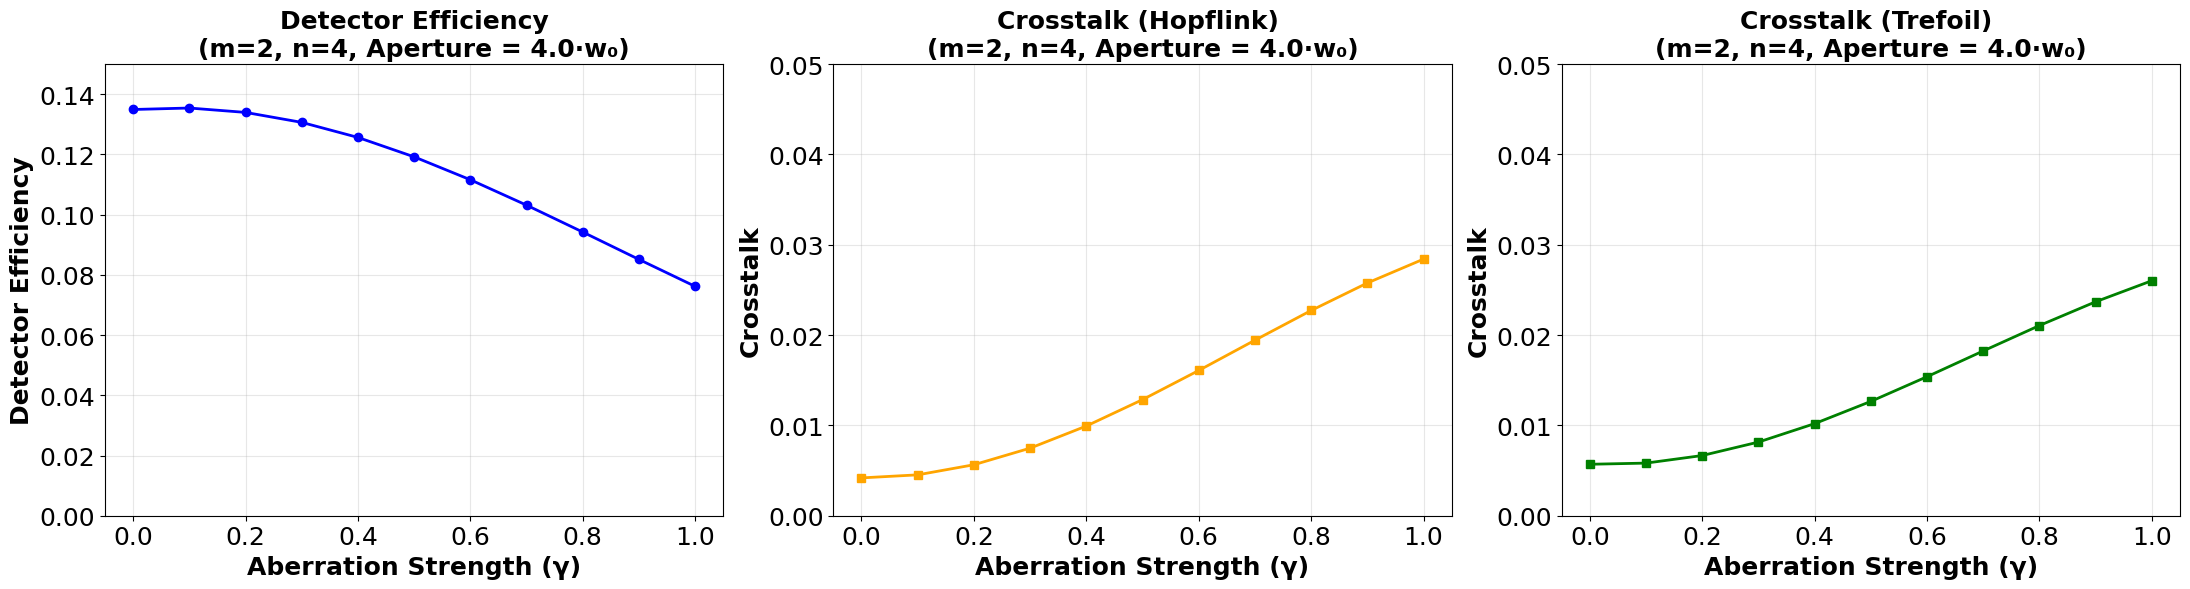

In [56]:

# Plot detector efficiency and crosstalk vs gamma as separate subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

# Plot detector efficiency
ax1.plot(gamma, effs, linewidth=2, marker='o', markersize=6, color='blue')
ax1.set_ylim(0.0, 0.15)  # Set y-axis limits
ax1.set_xlabel('Aberration Strength (γ)', fontsize=18, fontweight='bold')
ax1.set_ylabel('Detector Efficiency', fontsize=18, fontweight='bold')
ax1.set_title(f'Detector Efficiency\n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=18, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=18)

# Plot crosstalk 1
ax2.plot(gamma, crosses_1, linewidth=2, marker='s', markersize=6, color='orange')
ax2.set_ylim(0.000, 0.050)  # Set y-axis limits
ax2.set_xlabel('Aberration Strength (γ)', fontsize=18, fontweight='bold')
ax2.set_ylabel('Crosstalk', fontsize=18, fontweight='bold')
ax2.set_title(f'Crosstalk ({knotType[(mode+1)%3]}) \n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=18, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=18)

# Plot crosstalk 2
ax3.plot(gamma, crosses_2, linewidth=2, marker='s', markersize=6, color='green')
ax3.set_ylim(0.000, 0.050)  # Set y-axis limits
ax3.set_xlabel('Aberration Strength (γ)', fontsize=18, fontweight='bold')
ax3.set_ylabel('Crosstalk', fontsize=18, fontweight='bold')
ax3.set_title(f'Crosstalk ({knotType[(mode+2)%3]}) \n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=18, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='both', which='major', labelsize=18)

plt.tight_layout()
#plt.show()

plt.savefig(f'secondary_astig_{knotType[mode]}_{aperFactor}.pdf', bbox_inches='tight')


### Coma (n=3, m=1)

In [97]:
import time
from PIL import Image
import io

gamma = np.linspace(0, 1, 11)  # Fixed: creates 11 points from 0 to 1
m_n = (1, 3)
aperFactor = 8.0
aperature = aperFactor*w0

effs = []
crosses_1 = []
crosses_2 = []
frames = []  # Store frames for GIF

mode = 0

for ii in range(len(gamma)):
    # Generate aberrated knots 
    list_of_aberrated_OAMs = create_aberrated_knots(m_n, gamma[ii], aperature)
    
    # Create output field visualization for GIF (output modes only)
    d = len(list_of_aberrated_OAMs)
    fig, axes = plt.subplots(1, d, figsize=(6*d, 5))
    if d == 1:
        axes = [axes]
    
    for jj in range(d):
        # Compute output field (same logic as in visualize_input_output_fields)
        field = norm_field(list_of_aberrated_OAMs[jj].oamBeam, h)
        field_mod_1 = field * phase_maps[0]
        
        if multiPhase:
            field_after = field_mod_1
            for kk in range(1, len(phase_maps)):
                field_after = propTF(field_after, maxx, la, z_o)
                field_after = field_after * phase_maps[kk]
            final_field = propTF(field_after, maxx, la, z_o)
        else:
            if multiPhaseLens:
                field_after = field_mod_1
                for kk in range(1, num_phase_maps_near):
                    field_after = propTF(field_after, maxx, la, z_o)
                    field_after = field_after * phase_maps[kk]
                field_lens = fftshift(fft2(field_after))
            elif simulateLens:
                field_lens, _ = propFF(field_mod_1, maxx, la, fourier_lens)
            else:
                field_lens = fftshift(fft2(field_mod_1))
            
            if num_phase_maps_far == 0:
                final_field = field_lens
            else:
                field_mod_2 = field_lens * phase_maps[num_phase_maps_near]
                if multiPhaseLens:
                    field_after_2 = field_mod_2
                    for ll in range(1 + num_phase_maps_near, num_of_phase_maps):
                        field_after_2 = propTF(field_after_2, maxx, la, z_o)
                        field_after_2 = field_after_2 * phase_maps[ll]
                    field_lens_2 = ifft2(ifftshift(field_after_2))
                elif simulateLens:
                    field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
                else:
                    field_lens_2 = ifft2(ifftshift(field_mod_2))
                final_field = field_lens_2
        
        final_field = norm_field(final_field, h)
        output_intensity = np.abs(final_field)**2
        
        im = axes[jj].imshow(output_intensity, cmap='hot', extent=[-maxx/2, maxx/2, -maxx/2, maxx/2])
        axes[jj].set_title(f'Output Mode {jj+1} (γ={gamma[ii]:.2f})', fontsize=12, fontweight='bold')
        axes[jj].set_xlabel('x (m)', fontsize=10)
        axes[jj].set_ylabel('y (m)', fontsize=10)
        fig.colorbar(im, ax=axes[jj], fraction=0.046, pad=0.04)
        
        if jj < len(output_chans):
            axes[jj].contour(output_chans[jj], levels=[0.5], colors='cyan', linewidths=2, 
                           extent=[-maxx/2, maxx/2, -maxx/2, maxx/2], alpha=0.6)
    
    fig.tight_layout()
    
    # Save frame to memory
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    buf.close()
    plt.close(fig)
    
    # Compute the crosstalk matrix
    sorting_performance, crosstalk_matrix, _, _ = compute_sorting_performance(phase_maps, list_of_aberrated_OAMs)

    # Extract the desired crosstalk/detector efficency
    effs.append(crosstalk_matrix[mode, mode])
    crosses_1.append(crosstalk_matrix[mode, (mode+1)%3])
    crosses_2.append(crosstalk_matrix[mode, (mode+2)%3])

# Save GIF
gif_path = f'plots/coma_m{m_n[0]}_n{m_n[1]}_aper_{aperFactor}_output_modes.gif'
frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=500, loop=0)
print(f"GIF saved to: {gif_path}")


c:\Users\tjaouni\Desktop\Knot Sorter Project\KnotSorter\venv\Lib\site-packages\matplotlib\contour.py:1364: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = z.max().astype(float)
c:\Users\tjaouni\Desktop\Knot Sorter Project\KnotSorter\venv\Lib\site-packages\matplotlib\contour.py:1365: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = z.min().astype(float)
c:\Users\tjaouni\Desktop\Knot Sorter Project\KnotSorter\venv\Lib\site-packages\numpy\ma\core.py:2885: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_16452\1561749023.py:133: ComplexWarning: Casting complex values to real discards the imaginary part
  sorting_performance[ii] = correct_chans - incorrect_chans
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_16452\1561749023.py:137: ComplexWarning: Casting complex values to real discards the i

[0.12504627 0.12480236 0.13652853]
[0.1246364  0.12635321 0.13543451]
[0.11964435 0.12681095 0.1307139 ]
[0.11035154 0.12607056 0.12252791]
[0.09730785 0.12403015 0.11120839]
[0.08128571 0.12059593 0.09724638]
[0.06321513 0.11568849 0.0812718 ]
[0.04410634 0.10925004 0.06402508]
[0.02496779 0.10125214 0.04632155]
[0.00672787 0.09170317 0.02901021]
[-0.00983235  0.08065496  0.01292886]
GIF saved to: plots/coma_m1_n3_aper_8.0_output_modes.gif


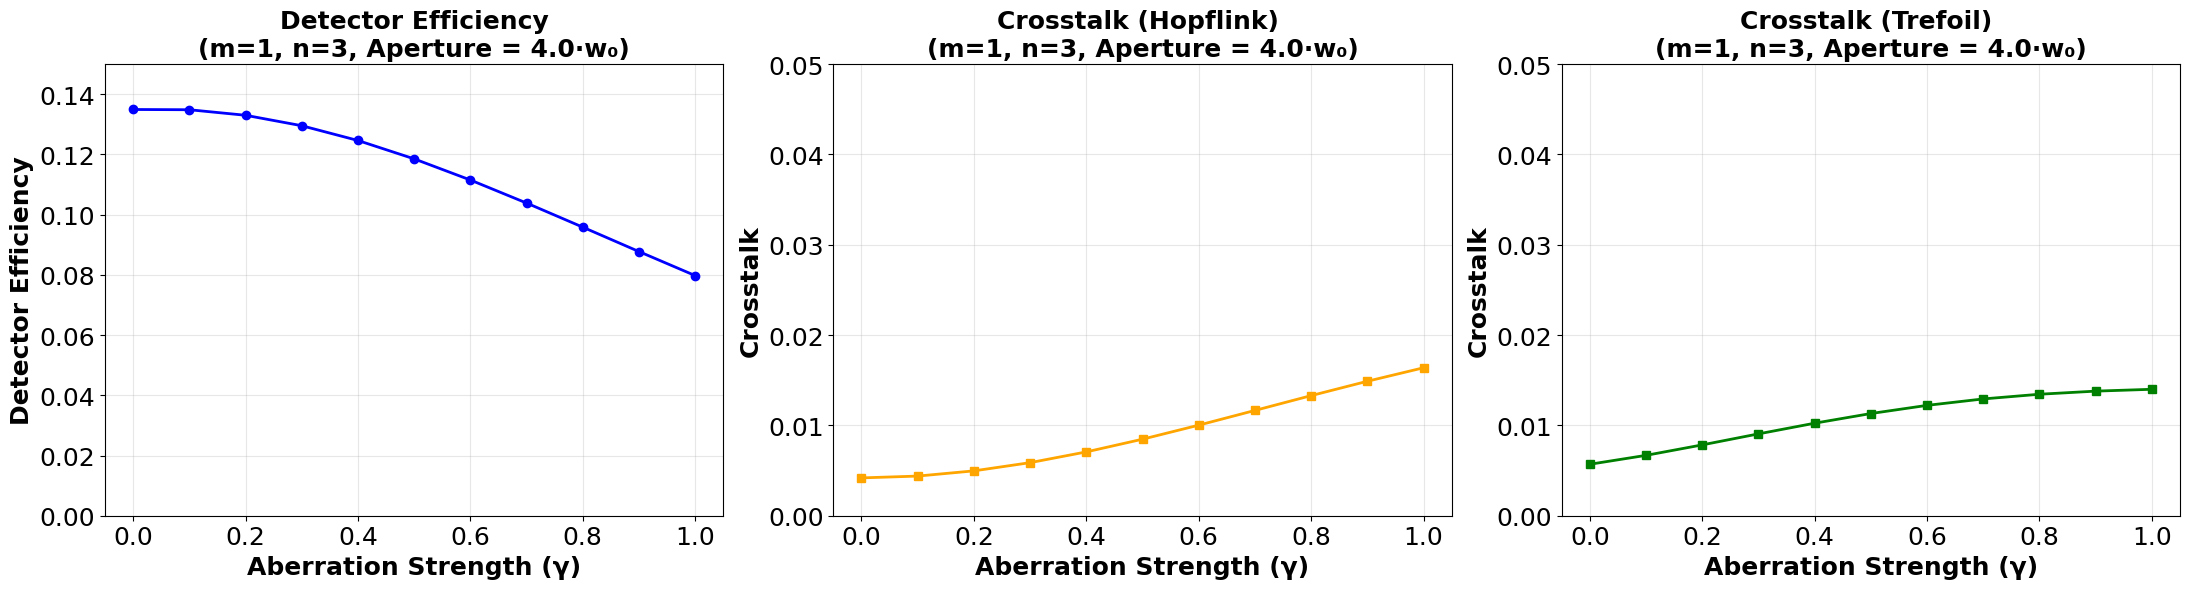

In [60]:
# Plot detector efficiency and crosstalk vs gamma as separate subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

# Plot detector efficiency
ax1.plot(gamma, effs, linewidth=2, marker='o', markersize=6, color='blue')
ax1.set_ylim(0.0, 0.15)  # Set y-axis limits
ax1.set_xlabel('Aberration Strength (γ)', fontsize=18, fontweight='bold')
ax1.set_ylabel('Detector Efficiency', fontsize=18, fontweight='bold')
ax1.set_title(f'Detector Efficiency\n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=18, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=18)

# Plot crosstalk 1
ax2.plot(gamma, crosses_1, linewidth=2, marker='s', markersize=6, color='orange')
ax2.set_ylim(0.000, 0.050)  # Set y-axis limits
ax2.set_xlabel('Aberration Strength (γ)', fontsize=18, fontweight='bold')
ax2.set_ylabel('Crosstalk', fontsize=18, fontweight='bold')
ax2.set_title(f'Crosstalk ({knotType[(mode+1)%3]}) \n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=18, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=18)


# Plot crosstalk 2
ax3.plot(gamma, crosses_2, linewidth=2, marker='s', markersize=6, color='green')
ax3.set_ylim(0.000, 0.050)  # Set y-axis limits
ax3.set_xlabel('Aberration Strength (γ)', fontsize=18, fontweight='bold')
ax3.set_ylabel('Crosstalk', fontsize=18, fontweight='bold')
ax3.set_title(f'Crosstalk ({knotType[(mode+2)%3]}) \n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=18, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='both', which='major', labelsize=18)

plt.tight_layout()
#plt.show()

plt.savefig(f'coma_{knotType[mode]}_{aperFactor}.pdf', bbox_inches='tight')

### Trefoil (n=3, m=3)

In [100]:
import time
from PIL import Image
import io

gamma = np.linspace(0, 1, 11)  # Fixed: creates 11 points from 0 to 1
m_n = (3, 3)
aperFactor =  4.0
aperature = aperFactor*w0

effs = []
crosses_1 = []
crosses_2 = []
frames = []  # Store frames for GIF

mode = 0

for ii in range(len(gamma)):
    # Generate aberrated knots 
    list_of_aberrated_OAMs = create_aberrated_knots(m_n, gamma[ii], aperature)
    
    # Create output field visualization for GIF (output modes only)
    d = len(list_of_aberrated_OAMs)
    fig, axes = plt.subplots(1, d, figsize=(6*d, 5))
    if d == 1:
        axes = [axes]
    
    for jj in range(d):
        # Compute output field (same logic as in visualize_input_output_fields)
        field = norm_field(list_of_aberrated_OAMs[jj].oamBeam, h)
        field_mod_1 = field * phase_maps[0]
        
        if multiPhase:
            field_after = field_mod_1
            for kk in range(1, len(phase_maps)):
                field_after = propTF(field_after, maxx, la, z_o)
                field_after = field_after * phase_maps[kk]
            final_field = propTF(field_after, maxx, la, z_o)
        else:
            if multiPhaseLens:
                field_after = field_mod_1
                for kk in range(1, num_phase_maps_near):
                    field_after = propTF(field_after, maxx, la, z_o)
                    field_after = field_after * phase_maps[kk]
                field_lens = fftshift(fft2(field_after))
            elif simulateLens:
                field_lens, _ = propFF(field_mod_1, maxx, la, fourier_lens)
            else:
                field_lens = fftshift(fft2(field_mod_1))
            
            if num_phase_maps_far == 0:
                final_field = field_lens
            else:
                field_mod_2 = field_lens * phase_maps[num_phase_maps_near]
                if multiPhaseLens:
                    field_after_2 = field_mod_2
                    for ll in range(1 + num_phase_maps_near, num_of_phase_maps):
                        field_after_2 = propTF(field_after_2, maxx, la, z_o)
                        field_after_2 = field_after_2 * phase_maps[ll]
                    field_lens_2 = ifft2(ifftshift(field_after_2))
                elif simulateLens:
                    field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
                else:
                    field_lens_2 = ifft2(ifftshift(field_mod_2))
                final_field = field_lens_2
        
        final_field = norm_field(final_field, h)
        output_intensity = np.abs(final_field)**2
        
        im = axes[jj].imshow(output_intensity, cmap='hot', extent=[-maxx/2, maxx/2, -maxx/2, maxx/2])
        axes[jj].set_title(f'Output Mode {jj+1} (γ={gamma[ii]:.2f})', fontsize=12, fontweight='bold')
        axes[jj].set_xlabel('x (m)', fontsize=10)
        axes[jj].set_ylabel('y (m)', fontsize=10)
        fig.colorbar(im, ax=axes[jj], fraction=0.046, pad=0.04)
        
        if jj < len(output_chans):
            axes[jj].contour(output_chans[jj], levels=[0.5], colors='cyan', linewidths=2, 
                           extent=[-maxx/2, maxx/2, -maxx/2, maxx/2], alpha=0.6)
    
    fig.tight_layout()
    
    # Save frame to memory
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    buf.close()
    plt.close(fig)
    
    # Compute the crosstalk matrix
    sorting_performance, crosstalk_matrix, _, _ = compute_sorting_performance(phase_maps, list_of_aberrated_OAMs)

    # Extract the desired crosstalk/detector efficency
    effs.append(crosstalk_matrix[mode, mode])
    crosses_1.append(crosstalk_matrix[mode, (mode+1)%3])
    crosses_2.append(crosstalk_matrix[mode, (mode+2)%3])

# Save GIF
gif_path = f'plots/trefoil_m{m_n[0]}_n{m_n[1]}_aper_{aperFactor}_output_modes.gif'
frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=500, loop=0)
print(f"GIF saved to: {gif_path}")


c:\Users\tjaouni\Desktop\Knot Sorter Project\KnotSorter\venv\Lib\site-packages\matplotlib\contour.py:1364: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = z.max().astype(float)
c:\Users\tjaouni\Desktop\Knot Sorter Project\KnotSorter\venv\Lib\site-packages\matplotlib\contour.py:1365: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = z.min().astype(float)
c:\Users\tjaouni\Desktop\Knot Sorter Project\KnotSorter\venv\Lib\site-packages\numpy\ma\core.py:2885: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_16452\1561749023.py:133: ComplexWarning: Casting complex values to real discards the imaginary part
  sorting_performance[ii] = correct_chans - incorrect_chans
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_16452\1561749023.py:137: ComplexWarning: Casting complex values to real discards the i

[0.12504627 0.12480236 0.13652853]
[0.12063247 0.12575055 0.13822099]
[0.11170449 0.12615696 0.13963862]
[0.09881409 0.12598468 0.14073183]
[0.0828267  0.12520361 0.1414227 ]
[0.06482291 0.12379415 0.14161615]
[0.04597555 0.12175067 0.1412137 ]
[0.02742077 0.11908425 0.14012786]
[0.01014162 0.11582419 0.13829496]
[-0.00511992  0.11201799  0.13568484]
[-0.01791208  0.10772961  0.13230604]
GIF saved to: plots/trefoil_m3_n3_aper_4.0_output_modes.gif


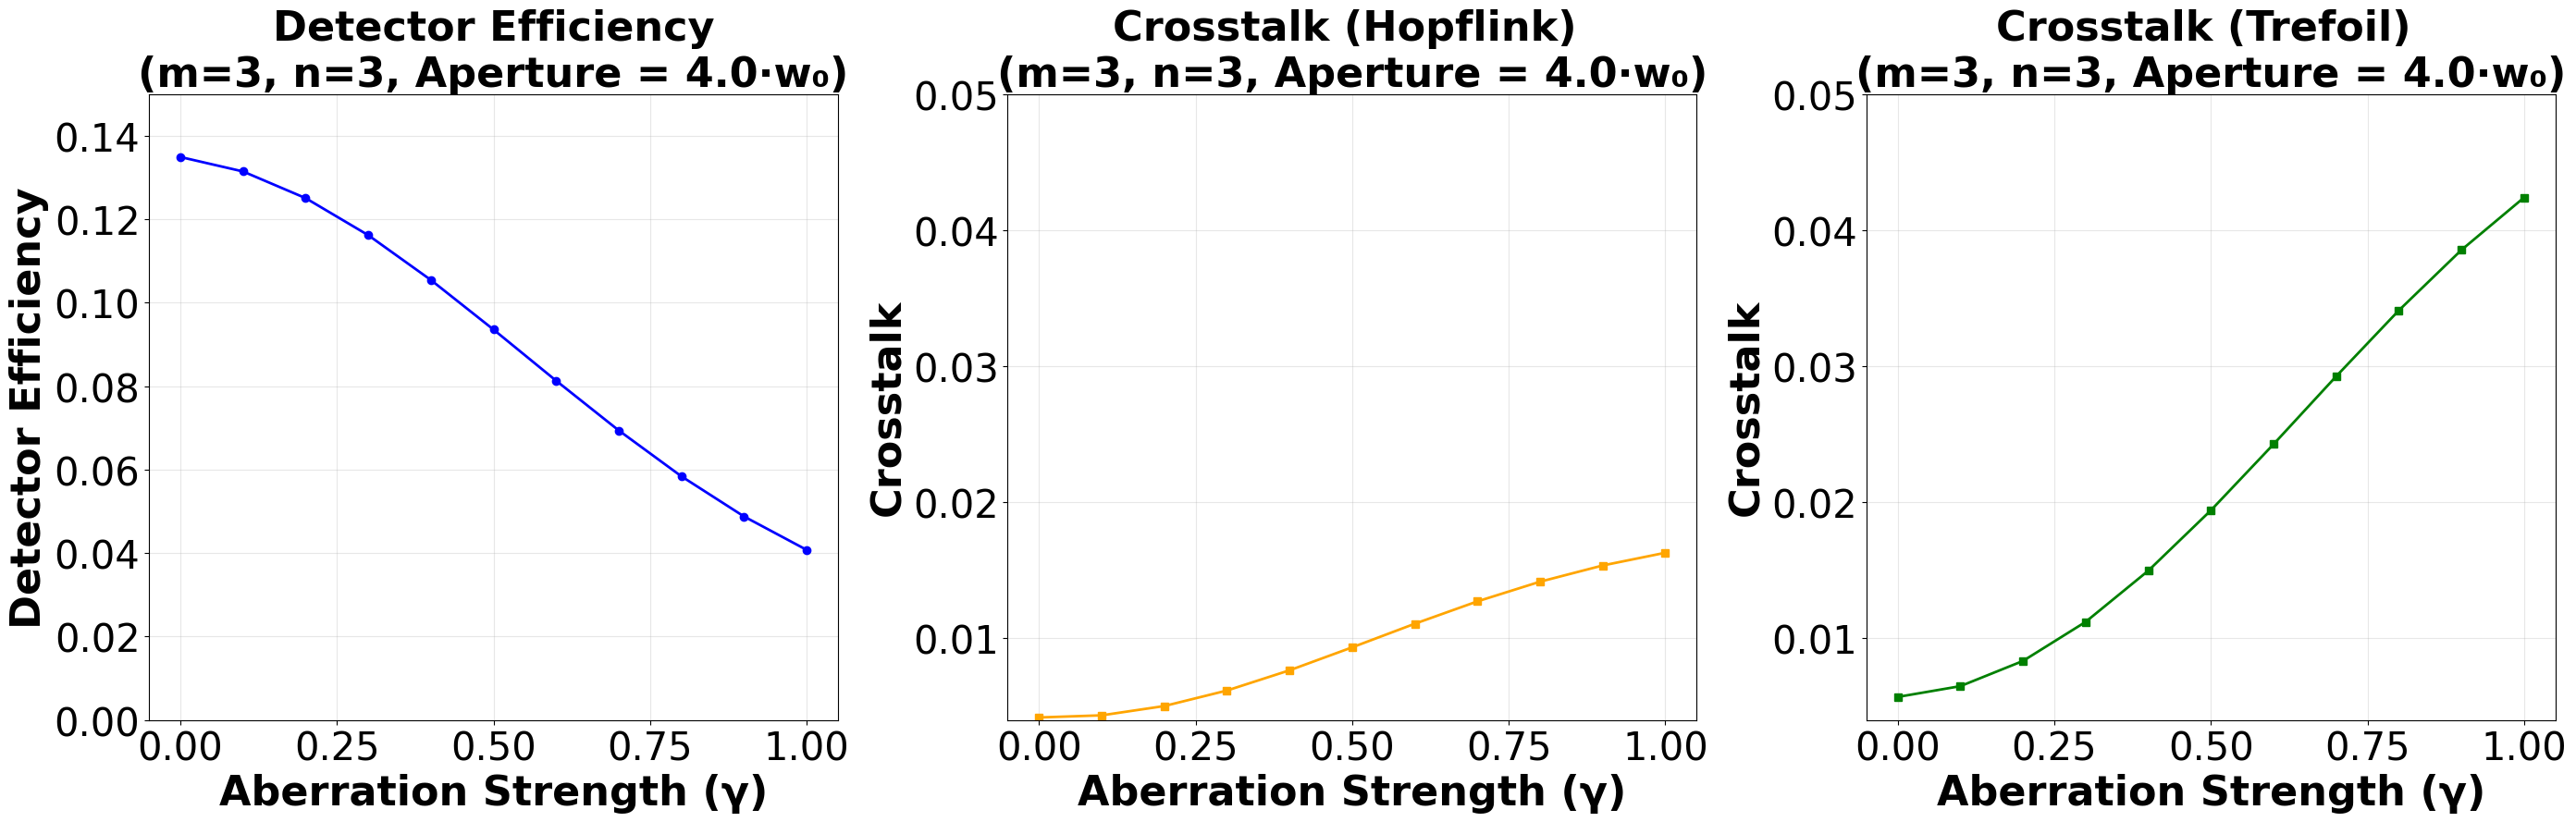

In [101]:
# Plot detector efficiency and crosstalk vs gamma as separate subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(28, 9))

# Plot detector efficiency
ax1.plot(gamma, effs, linewidth=2, marker='o', markersize=6, color='blue')
ax1.set_ylim(0.0, 0.15)  # Set y-axis limits
ax1.set_xlabel('Aberration Strength (γ)', fontsize=32, fontweight='bold')
ax1.set_ylabel('Detector Efficiency', fontsize=32, fontweight='bold')
ax1.set_title(f'Detector Efficiency\n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=32, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=30)

# Plot crosstalk 1
ax2.plot(gamma, crosses_1, linewidth=2, marker='s', markersize=6, color='orange')
ax2.set_ylim(0.004, 0.050)  # Set y-axis limits
ax2.set_xlabel('Aberration Strength (γ)', fontsize=32, fontweight='bold')
ax2.set_ylabel('Crosstalk', fontsize=32, fontweight='bold')
ax2.set_title(f'Crosstalk ({knotType[(mode+1)%3]}) \n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=32, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=30)


# Plot crosstalk 2
ax3.plot(gamma, crosses_2, linewidth=2, marker='s', markersize=6, color='green')
ax3.set_ylim(0.004, 0.050)  # Set y-axis limits
ax3.set_xlabel('Aberration Strength (γ)', fontsize=32, fontweight='bold')
ax3.set_ylabel('Crosstalk', fontsize=32, fontweight='bold')
ax3.set_title(f'Crosstalk ({knotType[(mode+2)%3]}) \n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=32, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='both', which='major', labelsize=30)

plt.tight_layout()
#plt.show()

plt.savefig(f'trefoil_{knotType[mode]})_{aperFactor}.pdf', bbox_inches='tight')

### Quadrafoil (n=4, m=4)

In [ ]:

gamma = np.linspace(0, 1, 11)  # Fixed: creates 11 points from 0 to 1
m_n = (4, 4)
aperFactor = 4.0
aperature = aperFactor*w0

effs = []
crosses_1 = []
crosses_2 = []
frames = []  # Store frames for GIF

mode = 0

for ii in range(len(gamma)):
    # Generate aberrated knots 
    list_of_aberrated_OAMs = create_aberrated_knots(m_n, gamma[ii], aperature)
    
    # Create output field visualization for GIF (output modes only)
    d = len(list_of_aberrated_OAMs)
    fig, axes = plt.subplots(1, d, figsize=(6*d, 5))
    if d == 1:
        axes = [axes]
    
    for jj in range(d):
        # Compute output field (same logic as in visualize_input_output_fields)
        field = norm_field(list_of_aberrated_OAMs[jj].oamBeam, h)
        field_mod_1 = field * phase_maps[0]
        
        if multiPhase:
            field_after = field_mod_1
            for kk in range(1, len(phase_maps)):
                field_after = propTF(field_after, maxx, la, z_o)
                field_after = field_after * phase_maps[kk]
            final_field = propTF(field_after, maxx, la, z_o)
        else:
            if multiPhaseLens:
                field_after = field_mod_1
                for kk in range(1, num_phase_maps_near):
                    field_after = propTF(field_after, maxx, la, z_o)
                    field_after = field_after * phase_maps[kk]
                field_lens = fftshift(fft2(field_after))
            elif simulateLens:
                field_lens, _ = propFF(field_mod_1, maxx, la, fourier_lens)
            else:
                field_lens = fftshift(fft2(field_mod_1))
            
            if num_phase_maps_far == 0:
                final_field = field_lens
            else:
                field_mod_2 = field_lens * phase_maps[num_phase_maps_near]
                if multiPhaseLens:
                    field_after_2 = field_mod_2
                    for ll in range(1 + num_phase_maps_near, num_of_phase_maps):
                        field_after_2 = propTF(field_after_2, maxx, la, z_o)
                        field_after_2 = field_after_2 * phase_maps[ll]
                    field_lens_2 = ifft2(ifftshift(field_after_2))
                elif simulateLens:
                    field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
                else:
                    field_lens_2 = ifft2(ifftshift(field_mod_2))
                final_field = field_lens_2
        
        final_field = norm_field(final_field, h)
        output_intensity = np.abs(final_field)**2
        
        im = axes[jj].imshow(output_intensity, cmap='hot', extent=[-maxx/2, maxx/2, -maxx/2, maxx/2])
        axes[jj].set_title(f'Output Mode {jj+1} (γ={gamma[ii]:.2f})', fontsize=12, fontweight='bold')
        axes[jj].set_xlabel('x (m)', fontsize=10)
        axes[jj].set_ylabel('y (m)', fontsize=10)
        fig.colorbar(im, ax=axes[jj], fraction=0.046, pad=0.04)
        
        if jj < len(output_chans):
            axes[jj].contour(output_chans[jj], levels=[0.5], colors='cyan', linewidths=2, 
                           extent=[-maxx/2, maxx/2, -maxx/2, maxx/2], alpha=0.6)
    
    fig.tight_layout()
    
    # Save frame to memory
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    buf.close()
    plt.close(fig)
    
    # Compute the crosstalk matrix
    sorting_performance, crosstalk_matrix, _, _ = compute_sorting_performance(phase_maps, list_of_aberrated_OAMs)

    # Extract the desired crosstalk/detector efficency
    effs.append(crosstalk_matrix[mode, mode])
    crosses_1.append(crosstalk_matrix[mode, (mode+1)%3])
    crosses_2.append(crosstalk_matrix[mode, (mode+2)%3])

# Save GIF
gif_path = f'plots/quadrafoil_m{m_n[0]}_n{m_n[1]}_aper_{aperFactor}_output_modes.gif'
frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=500, loop=0)
print(f"GIF saved to: {gif_path}")


c:\Users\tjaouni\Desktop\Knot Sorter Project\KnotSorter\venv\Lib\site-packages\matplotlib\contour.py:1364: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = z.max().astype(float)
c:\Users\tjaouni\Desktop\Knot Sorter Project\KnotSorter\venv\Lib\site-packages\matplotlib\contour.py:1365: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = z.min().astype(float)
c:\Users\tjaouni\Desktop\Knot Sorter Project\KnotSorter\venv\Lib\site-packages\numpy\ma\core.py:2885: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_20420\1561749023.py:133: ComplexWarning: Casting complex values to real discards the imaginary part
  sorting_performance[ii] = correct_chans - incorrect_chans
C:\Users\tjaouni\AppData\Local\Temp\ipykernel_20420\1561749023.py:137: ComplexWarning: Casting complex values to real discards the i

[0.12504627 0.12480236 0.13652853]
[0.12270233 0.1241565  0.13869969]
[0.11803882 0.12345163 0.14047115]
[0.11129861 0.12269929 0.14181863]
[0.1028258  0.12190462 0.14271588]
[0.09303958 0.12106688 0.14313741]
[0.08240192 0.12018051 0.14306175]
[0.07138193 0.11923645 0.14247503]
[0.060421   0.11822373 0.14137397]
[0.04990247 0.11713105 0.139768  ]
[0.04012922 0.1159482  0.13768002]
GIF saved to: plots/quadrafoil_m4_n4_aper_4.0_output_modes.gif


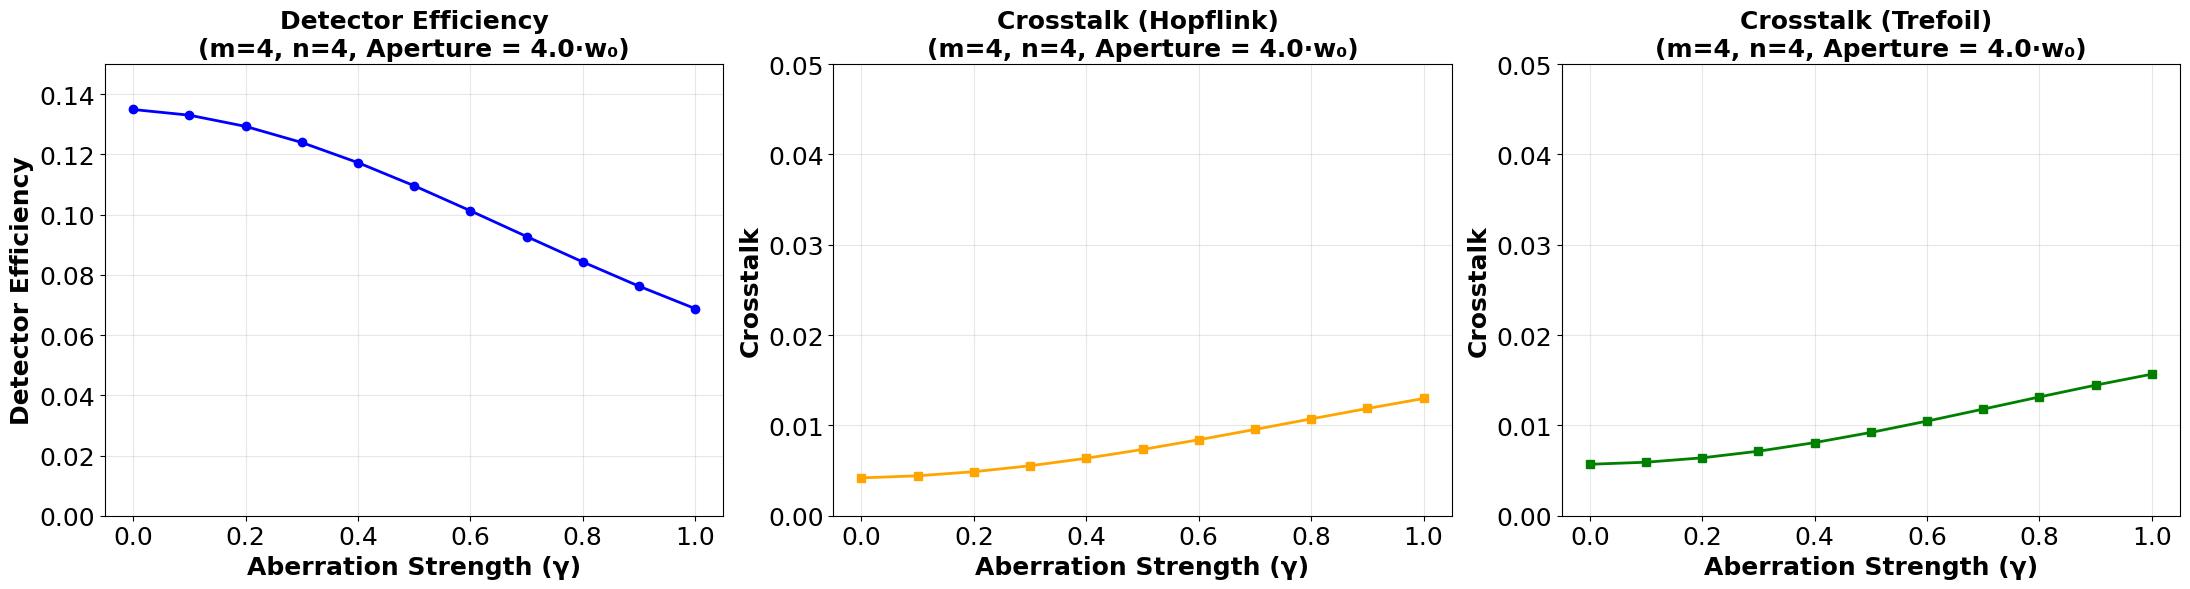

In [70]:
# Plot detector efficiency and crosstalk vs gamma as separate subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

# Plot detector efficiency
ax1.plot(gamma, effs, linewidth=2, marker='o', markersize=6, color='blue')
ax1.set_ylim(0.0, 0.15)  # Set y-axis limits
ax1.set_xlabel('Aberration Strength (γ)', fontsize=18, fontweight='bold')
ax1.set_ylabel('Detector Efficiency', fontsize=18, fontweight='bold')
ax1.set_title(f'Detector Efficiency\n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=18, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=18)

# Plot crosstalk 1
ax2.plot(gamma, crosses_1, linewidth=2, marker='s', markersize=6, color='orange')
ax2.set_ylim(0.000, 0.050)  # Set y-axis limits
ax2.set_xlabel('Aberration Strength (γ)', fontsize=18, fontweight='bold')
ax2.set_ylabel('Crosstalk', fontsize=18, fontweight='bold')
ax2.set_title(f'Crosstalk ({knotType[(mode+1)%3]}) \n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=18, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=18)


# Plot crosstalk 2
ax3.plot(gamma, crosses_2, linewidth=2, marker='s', markersize=6, color='green')
ax3.set_ylim(0.000, 0.050)  # Set y-axis limits
ax3.set_xlabel('Aberration Strength (γ)', fontsize=18, fontweight='bold')
ax3.set_ylabel('Crosstalk', fontsize=18, fontweight='bold')
ax3.set_title(f'Crosstalk ({knotType[(mode+2)%3]}) \n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=18, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='both', which='major', labelsize=18)

plt.tight_layout()
#plt.show()

plt.savefig(f'qudrafoil_{knotType[mode]}_{aperFactor}.pdf', bbox_inches='tight')


### Generate Aberrated Knots for Different Aberration Types

Create aberrated fields using different Zernike aberrations at maximum strength (γ=1)

In [23]:
# Parameters for aberration generation
gamma_strength = 1.0
aperFactor = 8.0
aperature = aperFactor * w0

# Define aberration types with their (m, n) Zernike indices
aberration_types = {
    'Secondary Astigmatism': (2, 4),
    'Coma': (1, 3),
    'Trefoil': (3, 3),
    'Quadrafoil': (4, 4)
}

# Generate aberrated knots for each aberration type
aberrated_fields = {}

for aberration_name, m_n in aberration_types.items():
    print(f"Generating {aberration_name} (m={m_n[0]}, n={m_n[1]})...")
    aberrated_fields[aberration_name] = create_aberrated_knots(m_n, gamma_strength, aperature)
    
print("\nAll aberrated fields generated successfully!")

Generating Secondary Astigmatism (m=2, n=4)...
Generating Coma (m=1, n=3)...
Generating Trefoil (m=3, n=3)...
Generating Quadrafoil (m=4, n=4)...

All aberrated fields generated successfully!


Visualize the aberrated fields for each aberration type

In [ ]:
# Visualize phase of each aberrated field separately
mode_to_plot = 0  # Plot the first mode

for aberration_name, m_n in aberration_types.items():
    # Get the aberrated field
    field = norm_field(aberrated_fields[aberration_name][mode_to_plot].oamBeam, h)
    
    # Create a separate figure for each aberration type showing only phase
    fig, ax = plt.subplots(1, 1, figsize=(8, 7))
    
    # Plot phase
    im = ax.imshow(np.angle(field), cmap='hsv', extent=[-maxx/2, maxx/2, -maxx/2, maxx/2])
    
    # Remove axes ticks
    ax.set_xticks([])
    ax.set_yticks([])
    
    plt.tight_layout()
    plt.show()

## Underwater Channel

We investigate how the knot sorter performs on a real channel, using a superposition of Zernike mode coefficents experimentally obtained in Fred's paper

In [ ]:
#ZernikeSuper(m_n_dict, RHO, PHI)


# Experimentally retrieved Zernike mode coefficents.
# In Fred's paper, the list of experimemtal coefficents are, according to their average values

# Format is m, n

fred_coeffs = {(0,0): 0.03, (-1,1): 0.09, (1,1): 0.11, (-2, 2): 0.17, (0, 2): 0.03, (2,2):0.15, (-3,3):0.01, (-1, 3): 0.01, (1, 3): 0.01, (3,3): 0.01 }

# Compute underwater phase

underwater_phase = ZernikeSuper(fred_coeffs, r, phi)

NameError: name 'RHO' is not defined

In [ ]:
# Create aberrated knots using the underwater phase
# Apply the underwater phase aberration to each input knot

list_of_underwater_OAMs = []

for ii in range(len(list_of_OAMs)):
    # Get the original field
    field = list_of_OAMs[ii].oamBeam
    
    # Apply the underwater phase aberration
    # Create aperture mask (using a similar aperture as in other experiments)
    aperture_size = 8.0 * w0
    aperture = (r <= aperture_size).astype(float)
    
    # Apply the Zernike superposition phase
    aberrated_field = field * np.exp(1j * underwater_phase) * aperture
    
    # Create new oamModes object with aberrated field
    list_of_underwater_OAMs.append(oamModes(aberrated_field, output_chans[ii]))

print("Underwater aberrated fields created successfully!")

# Compute sorting performance with underwater aberrations
sort_perf, crosstalk_matrix, secret_key, crosstalk_prob = compute_sorting_performance(
    phase_maps, list_of_underwater_OAMs, alpha=1.0
)

print("\n" + "="*60)
print("UNDERWATER CHANNEL PERFORMANCE METRICS")
print("="*60)

# Report average detector efficiency (diagonal elements of crosstalk matrix)
detector_efficiencies = np.diag(crosstalk_matrix)
avg_detector_eff = np.mean(detector_efficiencies)

print(f"\nDetector Efficiencies per mode:")
for i, eff in enumerate(detector_efficiencies):
    print(f"  Mode {i} ({knotType[i]}): {eff:.4f}")
print(f"\nAverage Detector Efficiency: {avg_detector_eff:.4f}")

# Report two-mode crosstalk (off-diagonal elements)
print(f"\nTwo-Mode Crosstalk Matrix:")
print(crosstalk_matrix)

# Calculate average crosstalk between different modes
off_diagonal_sum = 0
count = 0
for i in range(len(crosstalk_matrix)):
    for j in range(len(crosstalk_matrix)):
        if i != j:
            off_diagonal_sum += crosstalk_matrix[i, j]
            count += 1

avg_crosstalk = off_diagonal_sum / count if count > 0 else 0
print(f"\nAverage Two-Mode Crosstalk: {avg_crosstalk:.4f}")

# Report sorting ability (probabilities from crosstalk_prob matrix)
print(f"\nSorting Probabilities per mode:")
sorting_probs = np.diag(crosstalk_prob)
for i, prob in enumerate(sorting_probs):
    print(f"  Mode {i} ({knotType[i]}): {prob:.4f}")

avg_sorting_prob = np.mean(sorting_probs)
print(f"\nAverage Sorting Probability: {avg_sorting_prob:.4f}")

# Report overall sorting performance
print(f"\nOverall Sorting Performance: {sort_perf:.4f}")
print(f"Secret Key Rate: {secret_key:.4f} bits/photon")

print("="*60)

Now calculate the sorter performance and make a plot

# Varying the a,b parameters

Here, we investigate the effect of changing the a,b parameters to the input knot. Define the function which molds the knots to shape.

In [18]:
def mold_knots(a_offset, b_offset):

    '''
    generates aberrated knots 

    m_n -- tuple indicating the Zernike mode indices (m, n)
    gamma -- strength of the Zernike modes
    aperature -- aperature size of the aberration
    '''

    list_of_OAMs = []

    if(isKnot):
        for ii in range(len(knotType)):
            shapeParams_a, shapeParams_b, shapeParams_s = shapeParams[ii]
            # Introduce the offset for a, b, and s parameters (when applicable)
            shapeParams_a += a_offset
            shapeParams_b += b_offset
            # Put everything back together
            shapes = [shapeParams_a, shapeParams_b, shapeParams_s]
            field = setKnotType(r, phi, w0, knotType[ii], shapes)
            list_of_OAMs.append(oamModes(field, output_chans[ii]))
    else:
        for ii in range(len(LG_modes)):
            field = LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k)
            list_of_OAMs.append(oamModes(LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k), output_chans[ii]))
    
    return list_of_OAMs


Now generate the simulated knots. Define an a_offset and b_offset

In [19]:
a_offset = np.linspace(-1.0, 1.0, 100)
b_offset = np.linspace(-1.0, 1.0, 100)

Changing the a parameter of the knot

In [20]:
effs = []
cross = []

mode = 1

for a_off in a_offset: 
    # Generate the rotated fields
    list_of_melded_OAMs = mold_knots(a_off, 0)
    sorting_performance, crosstalk_matrix, _ = compute_sorting_performance(phase_maps, list_of_melded_OAMs)
    
    mean_eff = crosstalk_matrix[mode,mode]
    mean_cross = crosstalk_matrix[mode,(mode+1)%2]
    
    effs.append(mean_eff)
    cross.append(mean_cross)

Make a plot of how the detector efficency and crosstalk changes as a function of the a-parameter offset.

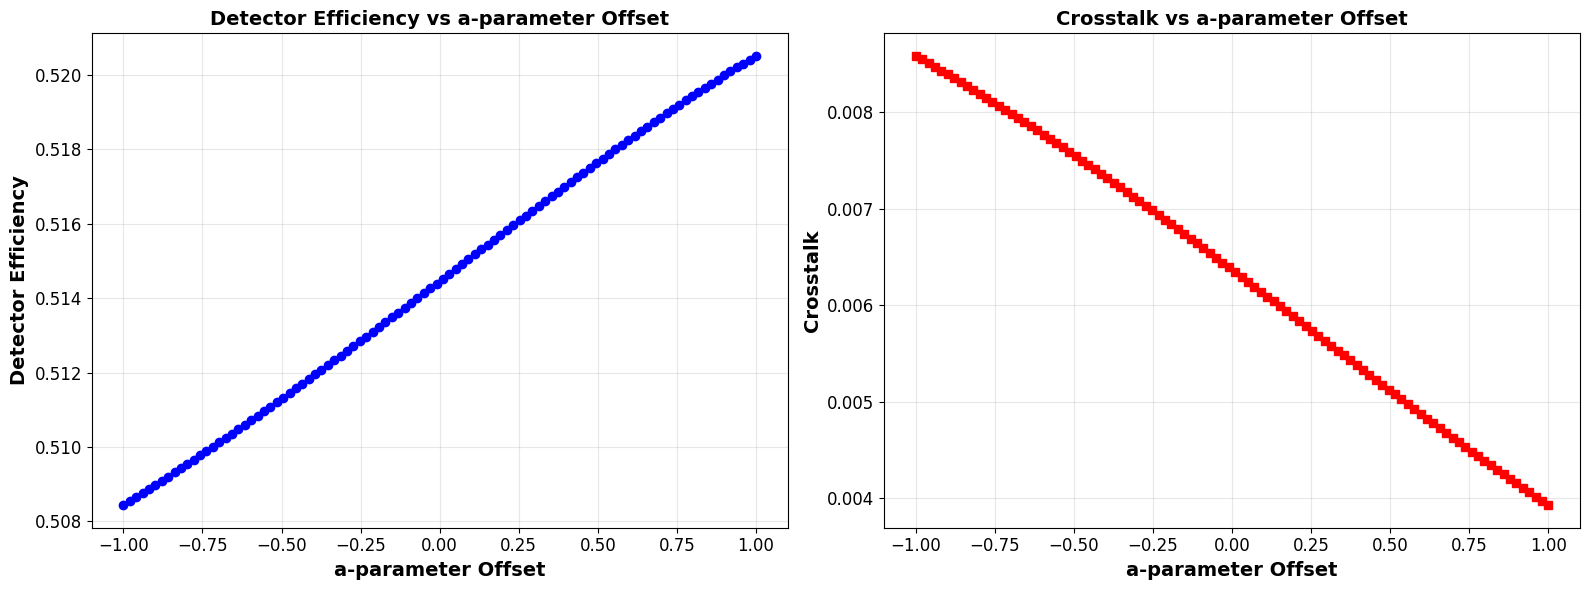

In [21]:
# Plot detector efficiency and crosstalk vs a-parameter offset as separate subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot detector efficiency
ax1.plot(a_offset, effs, linewidth=2, marker='o', markersize=6, color='blue')
ax1.set_xlabel('a-parameter Offset', fontsize=14, fontweight='bold')
ax1.set_ylabel('Detector Efficiency', fontsize=14, fontweight='bold')
ax1.set_title('Detector Efficiency vs a-parameter Offset', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=12)

# Plot crosstalk
ax2.plot(a_offset, cross, linewidth=2, marker='s', markersize=6, color='red')
ax2.set_xlabel('a-parameter Offset', fontsize=14, fontweight='bold')
ax2.set_ylabel('Crosstalk', fontsize=14, fontweight='bold')
ax2.set_title('Crosstalk vs a-parameter Offset', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.show()

Changing the b parameter of the knot

In [22]:
effs_b = []
cross_b = []

mode = 1

for b_off in b_offset: 
    # Generate the molded fields with b-parameter offset
    list_of_melded_OAMs = mold_knots(0, b_off)
    sorting_performance, crosstalk_matrix, _ = compute_sorting_performance(phase_maps, list_of_melded_OAMs)
    
    mean_eff = crosstalk_matrix[mode, mode]
    mean_cross = crosstalk_matrix[mode, (mode+1)%2]
    
    effs_b.append(mean_eff)
    cross_b.append(mean_cross)

Make a plot of how the detector efficency and crosstalk changes as a function of the b-parameter offset.

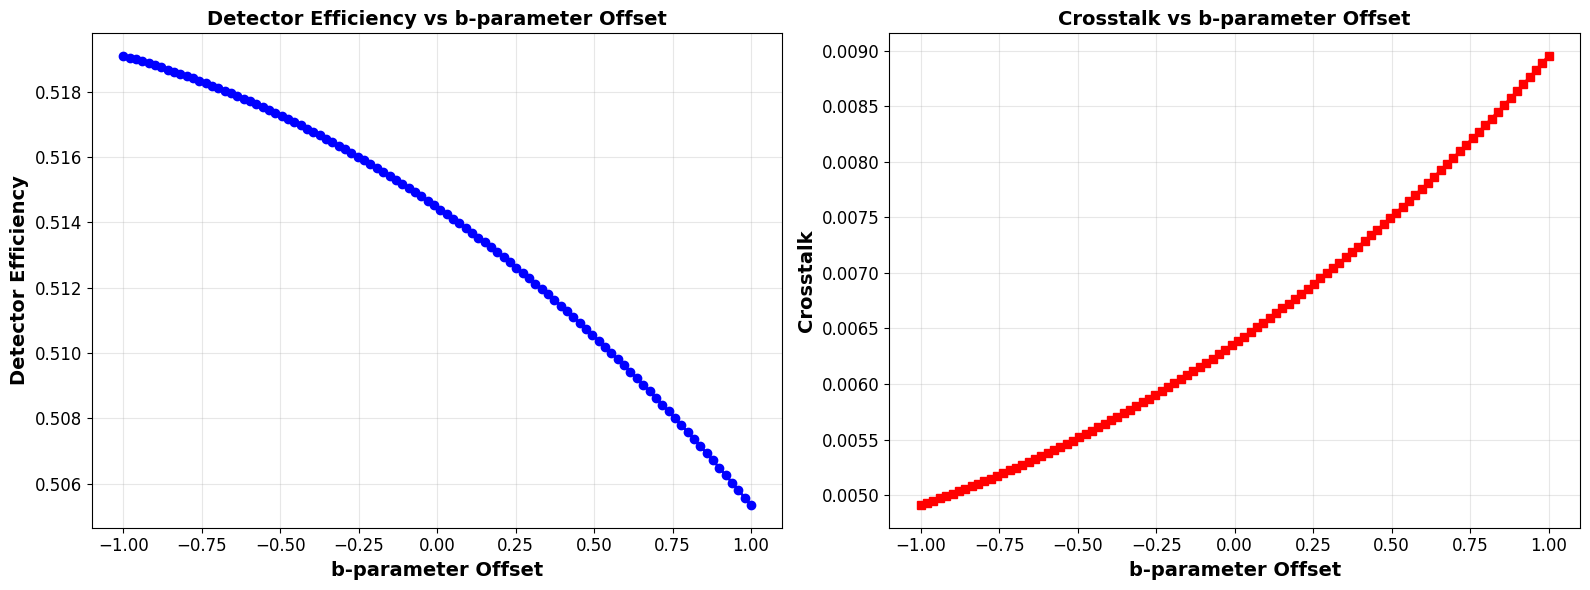

In [23]:
# Plot detector efficiency and crosstalk vs b-parameter offset as separate subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot detector efficiency
ax1.plot(b_offset, effs_b, linewidth=2, marker='o', markersize=6, color='blue')
ax1.set_xlabel('b-parameter Offset', fontsize=14, fontweight='bold')
ax1.set_ylabel('Detector Efficiency', fontsize=14, fontweight='bold')
ax1.set_title('Detector Efficiency vs b-parameter Offset', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=12)

# Plot crosstalk
ax2.plot(b_offset, cross_b, linewidth=2, marker='s', markersize=6, color='red')
ax2.set_xlabel('b-parameter Offset', fontsize=14, fontweight='bold')
ax2.set_ylabel('Crosstalk', fontsize=14, fontweight='bold')
ax2.set_title('Crosstalk vs b-parameter Offset', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.show()

### Movies for sweeping knot shape offsets (a and b)
Visualize how the sorter output evolves as we sweep the knot shape parameters a and b. Reuses the aberration movie workflow to create GIFs of the output intensities for each mode.

In [28]:
import os
import io
from PIL import Image


def generate_offset_gif(mode, offset_values, offset_type="a", gif_path=None, duration=200, dpi=100):
    """
    Create a GIF of output intensities while sweeping knot shape offsets.

    offset_values: iterable of offsets to sweep
    offset_type: "a" or "b" (which parameter to vary)
    gif_path: optional output path; defaults to plots/<offset_type>_offset_output_modes.gif
    duration: frame duration in ms
    dpi: resolution for saved frames
    """
    if gif_path is None:
        gif_path = f"plots/{offset_type}_offset_output_modes.gif"

    os.makedirs(os.path.dirname(gif_path) or ".", exist_ok=True)

    frames = []
    effs = []
    crosses = []

    for offset in offset_values:
        a_off = offset if offset_type == "a" else 0
        b_off = offset if offset_type == "b" else 0

        list_of_melded_OAMs = mold_knots(a_off, b_off)
        d = len(list_of_melded_OAMs)
        fig, axes = plt.subplots(1, d, figsize=(6 * d, 5))
        if d == 1:
            axes = [axes]

        for jj in range(d):
            # Compute output field (same logic as visualize_input_output_fields)
            field = norm_field(list_of_melded_OAMs[jj].oamBeam, h)
            field_mod_1 = field * phase_maps[0]

            if multiPhase:
                field_after = field_mod_1
                for kk in range(1, len(phase_maps)):
                    field_after = propTF(field_after, maxx, la, z_o)
                    field_after = field_after * phase_maps[kk]
                final_field = propTF(field_after, maxx, la, z_o)
            else:
                if multiPhaseLens:
                    field_after = field_mod_1
                    for kk in range(1, num_phase_maps_near):
                        field_after = propTF(field_after, maxx, la, z_o)
                        field_after = field_after * phase_maps[kk]
                    field_lens = fftshift(fft2(field_after))
                elif simulateLens:
                    field_lens, _ = propFF(field_mod_1, maxx, la, fourier_lens)
                else:
                    field_lens = fftshift(fft2(field_mod_1))

                if num_phase_maps_far == 0:
                    final_field = field_lens
                else:
                    field_mod_2 = field_lens * phase_maps[num_phase_maps_near]
                    if multiPhaseLens:
                        field_after_2 = field_mod_2
                        for ll in range(1 + num_phase_maps_near, num_of_phase_maps):
                            field_after_2 = propTF(field_after_2, maxx, la, z_o)
                            field_after_2 = field_after_2 * phase_maps[ll]
                        field_lens_2 = ifft2(ifftshift(field_after_2))
                    elif simulateLens:
                        field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
                    else:
                        field_lens_2 = ifft2(ifftshift(field_mod_2))
                    final_field = field_lens_2

            final_field = norm_field(final_field, h)
            output_intensity = np.abs(final_field) ** 2

            title_param = f"a = {a_off:+.2f}" if offset_type == "a" else f"b = {b_off:+.2f}"
            im = axes[jj].imshow(
                output_intensity,
                cmap="hot",
                extent=[-maxx / 2, maxx / 2, -maxx / 2, maxx / 2],
            )
            axes[jj].set_title(f"Output Mode {jj + 1} ({title_param})", fontsize=12, fontweight="bold")
            axes[jj].set_xlabel("x (m)", fontsize=10)
            axes[jj].set_ylabel("y (m)", fontsize=10)
            fig.colorbar(im, ax=axes[jj], fraction=0.046, pad=0.04)

            if jj < len(output_chans):
                axes[jj].contour(
                    output_chans[jj],
                    levels=[0.5],
                    colors="cyan",
                    linewidths=2,
                    extent=[-maxx / 2, maxx / 2, -maxx / 2, maxx / 2],
                    alpha=0.6,
                )

        fig.tight_layout()

        # Save frame to memory
        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
        buf.seek(0)
        frames.append(Image.open(buf).copy())
        buf.close()
        plt.close(fig)

        # Compute the crosstalk matrix to track metrics alongside the movie
        sorting_performance, crosstalk_matrix, _ = compute_sorting_performance(
            phase_maps, list_of_melded_OAMs
        )
        effs.append(crosstalk_matrix[mode, mode])
        crosses.append(crosstalk_matrix[mode, (mode + 1) % 2])

    frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=duration, loop=0)
    print(f"GIF saved to: {gif_path}")

    return np.array(effs), np.array(crosses)


GIF saved to: plots/a_offset_output_modes_{mode}.gif


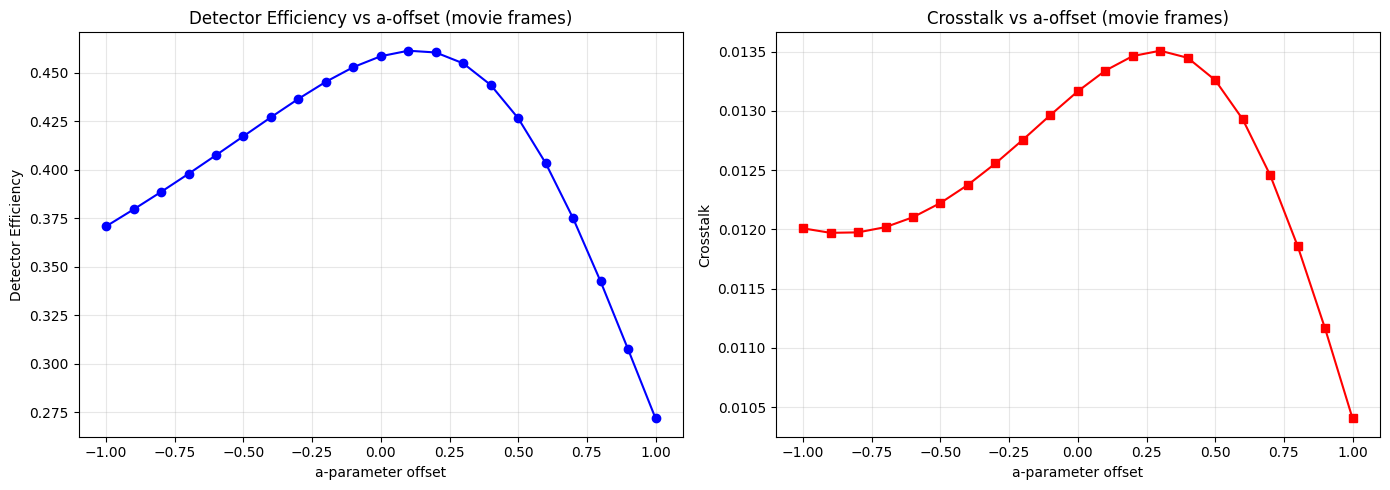

In [ ]:
# Generate GIF while sweeping the a-parameter offset
# Use fewer frames for reasonable GIF size while covering full range

a_offsets_for_gif = np.linspace(-1.0, 1.0, 21)
mode = 0
effs_a_movie, cross_a_movie = generate_offset_gif(
    mode,
    a_offsets_for_gif,
    offset_type="a",
    gif_path=f"plots/a_offset_output_modes_{mode}.gif",
    duration=200,
    dpi=120,
)

# Quick visualization of the metrics captured alongside the movie
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(a_offsets_for_gif, effs_a_movie, marker="o", color="blue")
ax1.set_title("Detector Efficiency vs a-offset (movie frames)")
ax1.set_xlabel("a-parameter offset")
ax1.set_ylabel("Detector Efficiency")
ax1.grid(True, alpha=0.3)

ax2.plot(a_offsets_for_gif, cross_a_movie, marker="s", color="red")
ax2.set_title("Crosstalk vs a-offset (movie frames)")
ax2.set_xlabel("a-parameter offset")
ax2.set_ylabel("Crosstalk")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


GIF saved to: plots/b_offset_output_modes_{mode}.gif


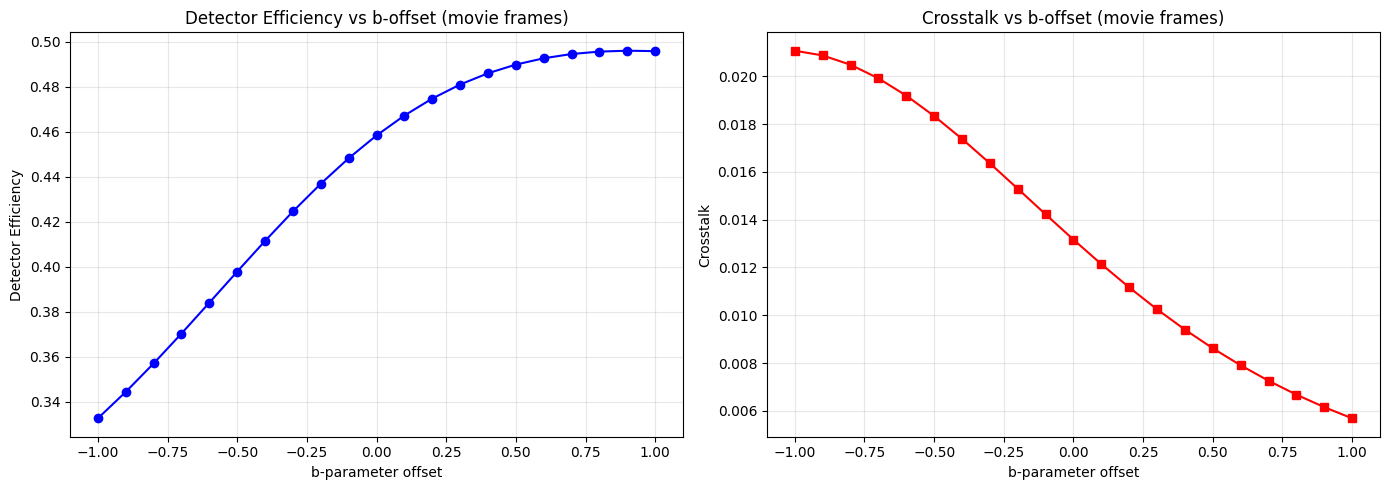

In [ ]:
# Generate GIF while sweeping the b-parameter offset

b_offsets_for_gif = np.linspace(-1.0, 1.0, 21)
mode = 0
effs_b_movie, cross_b_movie = generate_offset_gif(
    mode,
    b_offsets_for_gif,
    offset_type="b",
    gif_path=f"plots/b_offset_output_modes_{mode}.gif",
    duration=200,
    dpi=120,
)

# Quick visualization of the metrics captured alongside the movie
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(b_offsets_for_gif, effs_b_movie, marker="o", color="blue")
ax1.set_title("Detector Efficiency vs b-offset (movie frames)")
ax1.set_xlabel("b-parameter offset")
ax1.set_ylabel("Detector Efficiency")
ax1.grid(True, alpha=0.3)

ax2.plot(b_offsets_for_gif, cross_b_movie, marker="s", color="red")
ax2.set_title("Crosstalk vs b-offset (movie frames)")
ax2.set_xlabel("b-parameter offset")
ax2.set_ylabel("Crosstalk")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Simulated Experiment

Now, we proceed to compute our chosen, simulated experiment. We can run the experiment from here. 

In [ ]:
# Functions to import

import numpy as np 
import scipy as sp
import pygad
import yaml 
from yaml import Loader 

from scipy.fft import fft2, fftfreq, ifft2, fftshift, ifftshift
from scipy import ndimage
from optical_functions import TotInt, LG, propFF, cart2pol, oamModes, output_chan, setKnotType, output_chan_symmetric, output_chan_triangle, norm_field
from knot_funcs import propTF

import matplotlib.pyplot as plt 

import os

# Physical Constants

nm = 1e-9
um = 1e-6
mm = 1e-3
cm = 1e-2

Determine the experiment we are going to design

In [ ]:
simulateLens = cnfg['simulateLens']
multiPhase = cnfg['multiPhase']
multiPhaseLens = cnfg['multiPhaseLens']

z_o = cnfg['z_o']*cm
fourier_lens = cnfg['fourier_length']

Choose the LG beam to analyze

In [ ]:
mode_num = 0
field = norm_field(list_of_OAMs[mode_num].oamBeam, h)

# Compute the initial field intensity. Will be important for later

int_knot = np.sum(np.abs(field)**2)

Modulate the beam with the first phase screen (if applicable).

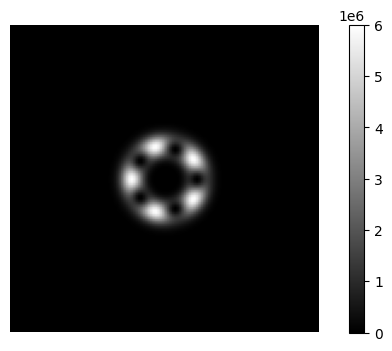

In [ ]:
# modulate the field by the first phase map 

field_mod_1 = field*phase_maps[0]

# plot the beam

TotInt(field_mod_1, phase=False)

Depending on what kind of experiment we choose to realize, we may opt to implement multiple phase screens. 

### Multiple Phase Screens only

In this experiment, we simply propagate the beam through multiple phase maps that we opt to optimize

![image.png](attachment:image.png)

In [ ]:
if (multiPhase): # Propagate the field by a distance z_o and apply the second phase screen
            field_after = field_mod_1

            for ii in range(1, len(phase_maps)):
                print(ii)
                # Propagate the beam by a distance z_o
                field_after = propTF(field_after, maxx, la, z_o)

                # Plot the beam 
                TotInt(field_after)
                plt.show()
                
                # Apply the next phase map (if applicable)
                field_after = field_after*phase_maps[ii]

            # Propagate the beam one final time and observe the final field

            final_field = propTF(field_after, maxx, la, z_o)


At this point, plot the final beam

In [ ]:
TotInt(final_field, phase=False)

NameError: name 'final_field' is not defined

### Multiple Phases with Lens

Alternatively, we create stacks of plates in the near field, then apply a lens (i.e. take the fourier transform)

![image.png](attachment:image.png)

In [ ]:
if (multiPhaseLens): # Multi-phase experiment with the lens
        field_after = field_mod_1

        #print(num_phase_maps_near)
        for ii in range(1, num_phase_maps_near):
            # Propagate the beam by a distance z_o 
            field_after = propTF(field_after, maxx, la, z_o)
            # Apply the next phase map in the near field (if applicable)
            field_after = field_after*phase_maps[ii]
                
        # Fourier transform the beam into the far field
        field_lens = fftshift(fft2(field_after))

Plot the field at the first focal plane of the lens

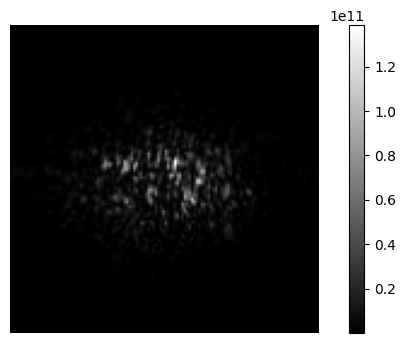

In [ ]:
TotInt(field_lens, phase=False)

Now, modulate the beam in the far field (if applicable)

In [ ]:
# What happens next depends on whether we have one or two phase maps
        
if (num_phase_maps_far==0):
    # Compute the field intensity 
    final_field = field_lens
        
else:
    # Modulate the field by the first far field map

    print(num_phase_maps_near)
    field_mod_2 = field_lens*phase_maps[num_phase_maps_near]

    if (multiPhaseLens):
        field_after_2 = field_mod_2
        
        #print(1+num_phase_maps_near)
        #print(num_of_phase_maps)

        for jj in range(1+num_phase_maps_near, num_of_phase_maps):
            print(jj)
            # Propagate the beam 
            field_after_2 = propTF(field_after_2, maxx, la, z_o)
            # Apply phase to beam 
            field_after_2 = field_after_2*phase_maps[jj]

        # Apply inverse fourier transform onto beam
        field_lens_2 = ifft2(ifftshift(field_after_2))

    final_field = field_lens_2

1


NameError: name 'field_lens' is not defined

Make a plot of the final field

In [ ]:
TotInt(final_field, phase=False)

NameError: name 'final_field' is not defined

### Standard Experiment 

This is the same procedure that we follow from Robert Fickler's paper, and what we have been doing up until now.
 ![image.png](attachment:image.png)

In [ ]:
if (simulateLens): # We simulate Faunhofer Diffraction for a more accurate representation of lens propagation
    field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)
    
else: # Compute the field at the front focal plane of the lens
    field_lens = fftshift(fft2(field_mod_1))

Make a plot of the field at the focal length of the lens 

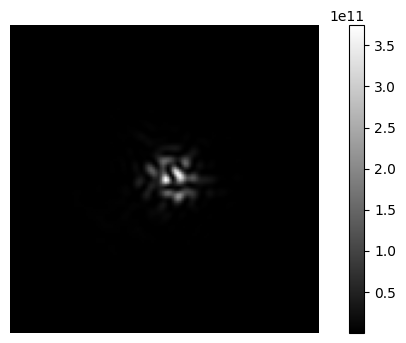

In [ ]:
TotInt(field_lens, phase=False)

Simulating the second phase map (if applicable)

In [ ]:
if (num_phase_maps_far == 0):
    final_field = field_lens

else:
    field_mod_2 = field_lens*phase_maps[num_phase_maps_near]

    if simulateLens:
        field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)

    else:
        field_lens_2 = ifft2(ifftshift(field_mod_2))

    final_field = field_lens_2

Make a plot of the field

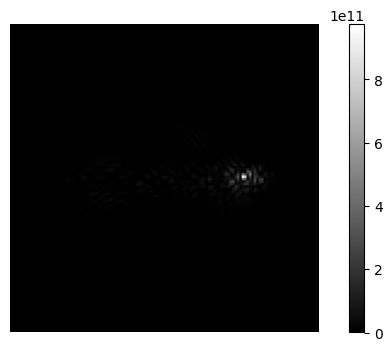

In [ ]:
TotInt(final_field, phase=False)